In [1]:
# =============================================================================
# CELL 1: IMPORT LIBRARIES, DEFINE SETTINGS AND CREATE HELPER FUNCTIONS
# =============================================================================
# This cell imports the required libraries, defines the main forecasting
# settings, creates folders for outputs and provides reusable functions for
# evaluating forecasts and testing stationarity.
# =============================================================================

import os
import time
import warnings
import itertools
from pathlib import Path

# Reduce unnecessary TensorFlow output when the LSTM model is executed.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Suppress non-critical warning messages.
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from IPython.display import display
from dateutil.easter import easter
from scipy import stats

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.estimators.hannan_rissanen import (
    hannan_rissanen
)

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error


# -----------------------------------------------------------------------------
# REPRODUCIBILITY SETTINGS
# -----------------------------------------------------------------------------

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# -----------------------------------------------------------------------------
# FORECASTING SETTINGS
# -----------------------------------------------------------------------------

# The final two years, equal to 104 weeks, are reserved for testing.
TEST_WEEKS = 104

# Weekly data are expected to contain annual seasonality.
SEASONAL_PERIOD = 52

# Temperature thresholds used to calculate heating and cooling degree days.
HEATING_BASE = 15.5
COOLING_BASE = 22.0


# -----------------------------------------------------------------------------
# OFFICIAL ELECTRICITY DATA SOURCE
# -----------------------------------------------------------------------------

# The dataset is loaded directly from the exact link provided in the
# assignment brief.
LOAD_SOURCE = (
    "https://data.open-power-system-data.org/time_series/"
    "2020-10-06/time_series_60min_singleindex.csv"
)


# -----------------------------------------------------------------------------
# OUTPUT FOLDERS
# -----------------------------------------------------------------------------

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DATA_DIR = Path("data")

for folder in [
    OUTPUT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    DATA_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# -----------------------------------------------------------------------------
# FORECAST EVALUATION FUNCTIONS
# -----------------------------------------------------------------------------

def calculate_rmse(y_true, y_pred):
    """
    Calculate root mean squared error.

    RMSE measures forecast error in gigawatts and gives greater importance
    to large forecast errors.
    """
    return float(
        np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )
    )


def calculate_smape(y_true, y_pred):
    """
    Calculate symmetric mean absolute percentage error.

    sMAPE expresses forecast error as a percentage and allows models with
    different error scales to be compared.
    """
    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    denominator = (
        np.abs(y_true)
        + np.abs(y_pred)
    )

    valid_values = denominator != 0

    return float(
        200
        * np.mean(
            np.abs(
                y_pred[valid_values]
                - y_true[valid_values]
            )
            / denominator[valid_values]
        )
    )


def calculate_mase(
    y_true,
    y_pred,
    y_train,
    seasonality=52
):
    """
    Calculate mean absolute scaled error.

    The model error is divided by the average error from a seasonal-naive
    forecast calculated using the training data.

    A MASE value below 1 indicates improvement over the seasonal-naive
    scaling benchmark.
    """
    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    y_train = np.asarray(
        y_train,
        dtype=float
    )

    seasonal_scale = np.mean(
        np.abs(
            y_train[seasonality:]
            - y_train[:-seasonality]
        )
    )

    return float(
        np.mean(
            np.abs(
                y_true - y_pred
            )
        )
        / seasonal_scale
    )


def evaluate_forecast(
    model_name,
    y_true,
    y_pred,
    y_train,
    forecast_type="Operational"
):
    """
    Calculate the main evaluation metrics for one forecasting model.

    Operational forecasts use only information available at the forecast
    origin. Conditional forecasts use observed future temperature values.
    """
    y_true = pd.Series(
        y_true
    ).astype(float)

    y_pred = pd.Series(
        y_pred,
        index=y_true.index
    ).astype(float)

    return {
        "Model": model_name,
        "Forecast type": forecast_type,

        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),

        "RMSE": calculate_rmse(
            y_true,
            y_pred
        ),

        "MASE": calculate_mase(
            y_true,
            y_pred,
            y_train,
            SEASONAL_PERIOD
        ),

        "sMAPE": calculate_smape(
            y_true,
            y_pred
        ),

        # Positive bias indicates overprediction.
        # Negative bias indicates underprediction.
        "Bias": float(
            np.mean(
                y_pred - y_true
            )
        )
    }


def run_stationarity_tests(
    series,
    series_name
):
    """
    Apply the Augmented Dickey-Fuller and KPSS stationarity tests.

    ADF null hypothesis:
    The series contains a unit root and is non-stationary.

    KPSS null hypothesis:
    The series is stationary.
    """
    series = pd.Series(
        series
    ).dropna()

    adf_result = adfuller(
        series,
        autolag="AIC"
    )

    try:
        kpss_result = kpss(
            series,
            regression="c",
            nlags="auto"
        )

        kpss_statistic = kpss_result[0]
        kpss_p_value = kpss_result[1]

    except Exception:
        kpss_statistic = np.nan
        kpss_p_value = np.nan

    return {
        "Series": series_name,
        "Observations": len(series),
        "ADF statistic": adf_result[0],
        "ADF p-value": adf_result[1],
        "KPSS statistic": kpss_statistic,
        "KPSS p-value": kpss_p_value
    }


def save_current_figure(filename):
    """
    Save the current figure at 300 DPI for use in the report.
    """
    plt.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


print("Environment prepared successfully.")
print(f"Electricity data source: {LOAD_SOURCE}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Environment prepared successfully.
Electricity data source: https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv
Output directory: /content/outputs


In [2]:
# =============================================================================
# CELL 2: LOAD ELECTRICITY DATA AND CREATE WEATHER-RELATED FEATURES
# =============================================================================
# This cell:
# 1. Loads German hourly electricity demand.
# 2. Performs basic data-quality checks.
# 3. Converts electricity demand from MW to GW.
# 4. Aggregates the hourly data to weekly average load.
# 5. Downloads Berlin daily temperature.
# 6. Creates weekly temperature, HDD and CDD features.
# 7. Creates German public-holiday variables.
# 8. Aligns electricity load, temperature and holidays by week.
# =============================================================================


# -----------------------------------------------------------------------------
# LOAD ONLY THE TWO COLUMNS REQUIRED FOR THE ANALYSIS
# -----------------------------------------------------------------------------
# Reading only the required columns reduces memory use and execution time.
load_data = pd.read_csv(
    LOAD_SOURCE,
    usecols=[
        "utc_timestamp",
        "DE_load_actual_entsoe_transparency"
    ],
    parse_dates=["utc_timestamp"]
)


# Rename columns to shorter and more readable names.
load_data = load_data.rename(
    columns={
        "utc_timestamp": "date",
        "DE_load_actual_entsoe_transparency": "load_mw"
    }
)


# Convert the timestamp to timezone-aware UTC and then remove the timezone.
# A timezone-free DatetimeIndex simplifies resampling and alignment.
load_data["date"] = (
    pd.to_datetime(
        load_data["date"],
        utc=True
    )
    .dt.tz_convert(None)
)


# Ensure that observations are arranged chronologically.
load_data = load_data.sort_values(
    "date"
)


# Count duplicate timestamps before removing them.
duplicate_timestamp_count = int(
    load_data["date"]
    .duplicated()
    .sum()
)


# Remove duplicate timestamps and use the timestamp as the index.
load_data = (
    load_data
    .drop_duplicates(
        subset="date"
    )
    .set_index("date")
)


# The assignment requires data from 1 January 2015 onwards.
load_data = load_data.loc[
    "2015-01-01":
]


# Convert the load column to numeric format.
# Any invalid text value would become a missing value.
load_data["load_mw"] = pd.to_numeric(
    load_data["load_mw"],
    errors="coerce"
)


# -----------------------------------------------------------------------------
# CREATE THE HOURLY, DAILY AND WEEKLY ELECTRICITY SERIES
# -----------------------------------------------------------------------------

# Enforce a regular hourly frequency.
# This also reveals any missing timestamps in the original data.
hourly_load_mw = (
    load_data["load_mw"]
    .asfreq("h")
)


# Convert megawatts to gigawatts for easier interpretation in figures.
hourly_load_gw = (
    hourly_load_mw / 1000
)

hourly_load_gw.name = "load_gw"


# Daily averages are retained for exploratory analysis if needed.
daily_load_gw = (
    hourly_load_gw
    .resample("D")
    .mean()
)


# Count the number of hourly observations inside each weekly period.
# A complete week should contain exactly 168 hourly observations.
weekly_hour_counts = (
    hourly_load_gw
    .resample("W-SUN")
    .count()
)


# Calculate weekly mean electricity load.
weekly_load_gw = (
    hourly_load_gw
    .resample("W-SUN")
    .mean()
)


# Keep only complete weeks.
# This removes the incomplete first and final calendar weeks.
complete_week_dates = (
    weekly_hour_counts[
        weekly_hour_counts == 168
    ].index
)

weekly_load_gw = (
    weekly_load_gw
    .loc[complete_week_dates]
)

weekly_load_gw.name = "load_gw"


# -----------------------------------------------------------------------------
# FUNCTION TO DOWNLOAD BERLIN TEMPERATURE
# -----------------------------------------------------------------------------

def download_berlin_temperature(
    start_date,
    end_date,
    cache_file
):
    """
    Download Berlin daily mean temperature from Open-Meteo.

    The file is saved locally after the first download. Later notebook runs
    load the cached CSV, avoiding repeated API calls and reducing runtime.
    """
    cache_file = Path(
        cache_file
    )

    if cache_file.exists():

        cached_temperature = pd.read_csv(
            cache_file,
            parse_dates=["date"]
        )

        cached_temperature = (
            cached_temperature
            .set_index("date")
            .sort_index()
        )

        print(
            "Berlin temperature loaded "
            "from the local cached file."
        )

        return cached_temperature

    temperature_url = (
        "https://archive-api.open-meteo.com/"
        "v1/archive"
    )

    temperature_parameters = {
        "latitude": 52.52,
        "longitude": 13.41,

        "start_date": str(
            pd.Timestamp(
                start_date
            ).date()
        ),

        "end_date": str(
            pd.Timestamp(
                end_date
            ).date()
        ),

        "daily": "temperature_2m_mean",
        "timezone": "Europe/Berlin"
    }

    response = requests.get(
        temperature_url,
        params=temperature_parameters,
        timeout=120
    )

    response.raise_for_status()

    daily_temperature_json = (
        response.json()["daily"]
    )

    temperature_frame = pd.DataFrame(
        {
            "date": pd.to_datetime(
                daily_temperature_json[
                    "time"
                ]
            ),

            "temperature_2m_mean": (
                pd.to_numeric(
                    daily_temperature_json[
                        "temperature_2m_mean"
                    ]
                )
            )
        }
    )

    temperature_frame = (
        temperature_frame
        .set_index("date")
        .sort_index()
    )

    temperature_frame.reset_index().to_csv(
        cache_file,
        index=False
    )

    print(
        "Berlin temperature downloaded "
        "and saved locally."
    )

    return temperature_frame


# -----------------------------------------------------------------------------
# FUNCTION TO IDENTIFY NATIONAL GERMAN PUBLIC HOLIDAYS
# -----------------------------------------------------------------------------

def german_national_holidays(year):
    """
    Return the main national German public-holiday dates for one year.

    Fixed-date and Easter-related holidays are included. National holidays
    are used because the electricity target represents total German load,
    rather than demand from one German state.
    """
    easter_sunday = pd.Timestamp(
        easter(year)
    )

    holiday_dates = {
        # New Year's Day
        pd.Timestamp(
            year=year,
            month=1,
            day=1
        ),

        # Good Friday
        easter_sunday
        - pd.Timedelta(days=2),

        # Easter Monday
        easter_sunday
        + pd.Timedelta(days=1),

        # Labour Day
        pd.Timestamp(
            year=year,
            month=5,
            day=1
        ),

        # Ascension Day
        easter_sunday
        + pd.Timedelta(days=39),

        # Whit Monday
        easter_sunday
        + pd.Timedelta(days=50),

        # German Unity Day
        pd.Timestamp(
            year=year,
            month=10,
            day=3
        ),

        # Christmas Day
        pd.Timestamp(
            year=year,
            month=12,
            day=25
        ),

        # Second Christmas Day
        pd.Timestamp(
            year=year,
            month=12,
            day=26
        )
    }

    return holiday_dates


# -----------------------------------------------------------------------------
# DOWNLOAD AND PREPARE DAILY BERLIN TEMPERATURE
# -----------------------------------------------------------------------------

temperature_daily = (
    download_berlin_temperature(
        start_date=hourly_load_gw.index.min(),
        end_date=hourly_load_gw.index.max(),
        cache_file=(
            DATA_DIR
            / "berlin_temperature_daily.csv"
        )
    )
)


# Extract the daily mean temperature as a numeric series.
daily_temperature = (
    temperature_daily[
        "temperature_2m_mean"
    ]
    .astype(float)
)


# -----------------------------------------------------------------------------
# CREATE HEATING AND COOLING DEGREE-DAY FEATURES
# -----------------------------------------------------------------------------
# Heating degree days measure how far temperature falls below 15.5°C.
# Cooling degree days measure how far temperature rises above 22°C.
#
# These variables allow cold and hot weather to affect electricity demand
# differently instead of forcing one straight-line temperature relationship.
# -----------------------------------------------------------------------------

daily_heating_degree = np.maximum(
    HEATING_BASE - daily_temperature,
    0
)

daily_cooling_degree = np.maximum(
    daily_temperature - COOLING_BASE,
    0
)


# -----------------------------------------------------------------------------
# AGGREGATE DAILY TEMPERATURE TO WEEKLY FEATURES
# -----------------------------------------------------------------------------

weekly_temperature = pd.DataFrame(
    index=(
        daily_temperature
        .resample("W-SUN")
        .mean()
        .index
    )
)

weekly_temperature["temp_mean"] = (
    daily_temperature
    .resample("W-SUN")
    .mean()
)

weekly_temperature["temp_min"] = (
    daily_temperature
    .resample("W-SUN")
    .min()
)

weekly_temperature["temp_max"] = (
    daily_temperature
    .resample("W-SUN")
    .max()
)

weekly_temperature["heating_degree"] = (
    daily_heating_degree
    .resample("W-SUN")
    .sum()
)

weekly_temperature["cooling_degree"] = (
    daily_cooling_degree
    .resample("W-SUN")
    .sum()
)


# -----------------------------------------------------------------------------
# CREATE DAILY AND WEEKLY HOLIDAY VARIABLES
# -----------------------------------------------------------------------------

holiday_date_index = pd.date_range(
    start=temperature_daily.index.min().normalize(),
    end=temperature_daily.index.max().normalize(),
    freq="D"
)

daily_holidays = pd.DataFrame(
    index=holiday_date_index
)

all_holiday_dates = set()

for year in range(
    holiday_date_index.min().year,
    holiday_date_index.max().year + 1
):
    all_holiday_dates.update(
        german_national_holidays(year)
    )


# Binary indicator showing whether each date is a national public holiday.
daily_holidays["holiday_days"] = (
    daily_holidays.index
    .isin(all_holiday_dates)
    .astype(int)
)


# Christmas and New Year may produce stronger demand changes than ordinary
# holidays, so they are represented through a separate indicator.
daily_holidays["christmas_new_year"] = (
    daily_holidays.index
    .strftime("%m-%d")
    .isin(
        [
            "12-24",
            "12-25",
            "12-26",
            "12-31",
            "01-01"
        ]
    )
    .astype(int)
)


# Aggregate the daily holiday information to weekly frequency.
weekly_holidays = pd.DataFrame(
    index=(
        daily_holidays
        .resample("W-SUN")
        .sum()
        .index
    )
)

weekly_holidays["holiday_days"] = (
    daily_holidays[
        "holiday_days"
    ]
    .resample("W-SUN")
    .sum()
)

weekly_holidays["christmas_new_year"] = (
    daily_holidays[
        "christmas_new_year"
    ]
    .resample("W-SUN")
    .max()
)


# -----------------------------------------------------------------------------
# ALIGN WEEKLY LOAD, TEMPERATURE AND HOLIDAY INFORMATION
# -----------------------------------------------------------------------------

weekly_data = pd.DataFrame(
    {
        "load_gw": weekly_load_gw
    }
)

weekly_data = weekly_data.join(
    weekly_temperature,
    how="left"
)

weekly_data = weekly_data.join(
    weekly_holidays,
    how="left"
)


# -----------------------------------------------------------------------------
# CREATE LAGGED TEMPERATURE FEATURES
# -----------------------------------------------------------------------------
# shift(1) means that the current week's feature uses the previous week's
# temperature. This avoids using future temperature in a lagged predictor.
# -----------------------------------------------------------------------------

weekly_data["temp_lag_1"] = (
    weekly_data["temp_mean"]
    .shift(1)
)

weekly_data["temp_lag_2"] = (
    weekly_data["temp_mean"]
    .shift(2)
)

weekly_data["hdd_lag_1"] = (
    weekly_data["heating_degree"]
    .shift(1)
)

weekly_data["cdd_lag_1"] = (
    weekly_data["cooling_degree"]
    .shift(1)
)


# The rolling average is shifted before calculation so that it does not
# contain the current week's temperature.
weekly_data["temp_roll_4"] = (
    weekly_data["temp_mean"]
    .shift(1)
    .rolling(window=4)
    .mean()
)


# Remove rows missing essential current-week variables.
# Lagged values are allowed to remain missing at the beginning and are removed
# later when machine-learning features are constructed.
weekly_data = weekly_data.dropna(
    subset=[
        "load_gw",
        "temp_mean",
        "temp_min",
        "temp_max",
        "heating_degree",
        "cooling_degree",
        "holiday_days",
        "christmas_new_year"
    ]
).copy()


# Save the final aligned weekly dataset for reproducibility.
weekly_data.to_csv(
    DATA_DIR
    / "weekly_load_weather.csv"
)


# -----------------------------------------------------------------------------
# DISPLAY DATA-QUALITY SUMMARY
# -----------------------------------------------------------------------------

data_quality_summary = pd.DataFrame(
    {
        "Quality check": [
            "Hourly observations",
            "Missing hourly load values",
            "Duplicate timestamps removed",
            "Complete weekly observations",
            "Weekly start date",
            "Weekly end date"
        ],

        "Result": [
            len(hourly_load_gw),
            int(
                hourly_load_gw
                .isna()
                .sum()
            ),
            duplicate_timestamp_count,
            len(weekly_data),
            weekly_data.index.min().date(),
            weekly_data.index.max().date()
        ]
    }
)

display(
    data_quality_summary
)

display(
    weekly_data.head()
)

print(
    "Final weekly dataset shape:",
    weekly_data.shape
)

Berlin temperature downloaded and saved locally.


,Quality check,Result
0,Hourly observations,50400
1,Missing hourly load values,0
2,Duplicate timestamps removed,0
3,Complete weekly observations,299
4,Weekly start date,2015-01-11
5,Weekly end date,2020-09-27


,load_gw,temp_mean,temp_min,temp_max,heating_degree,cooling_degree,holiday_days,christmas_new_year,temp_lag_1,temp_lag_2,hdd_lag_1,cdd_lag_1,temp_roll_4
date,,,,,,,,,,,,,
2015-01-11,56.191101,3.885714,1.2,8.5,81.3,0.0,0,0,NaN,NaN,NaN,NaN,NaN
2015-01-18,57.672679,4.900000,-0.8,9.2,74.2,0.0,0,0,3.885714,NaN,81.3,0.0,NaN
2015-01-25,58.613304,0.028571,-0.7,0.9,108.3,0.0,0,0,4.900000,3.885714,74.2,0.0,NaN
2015-02-01,58.734030,1.414286,-0.1,2.8,98.6,0.0,0,0,0.028571,4.900000,108.3,0.0,NaN
2015-02-08,59.323899,-1.228571,-2.6,0.7,117.1,0.0,0,0,1.414286,0.028571,98.6,0.0,2.557143


Final weekly dataset shape: (299, 13)


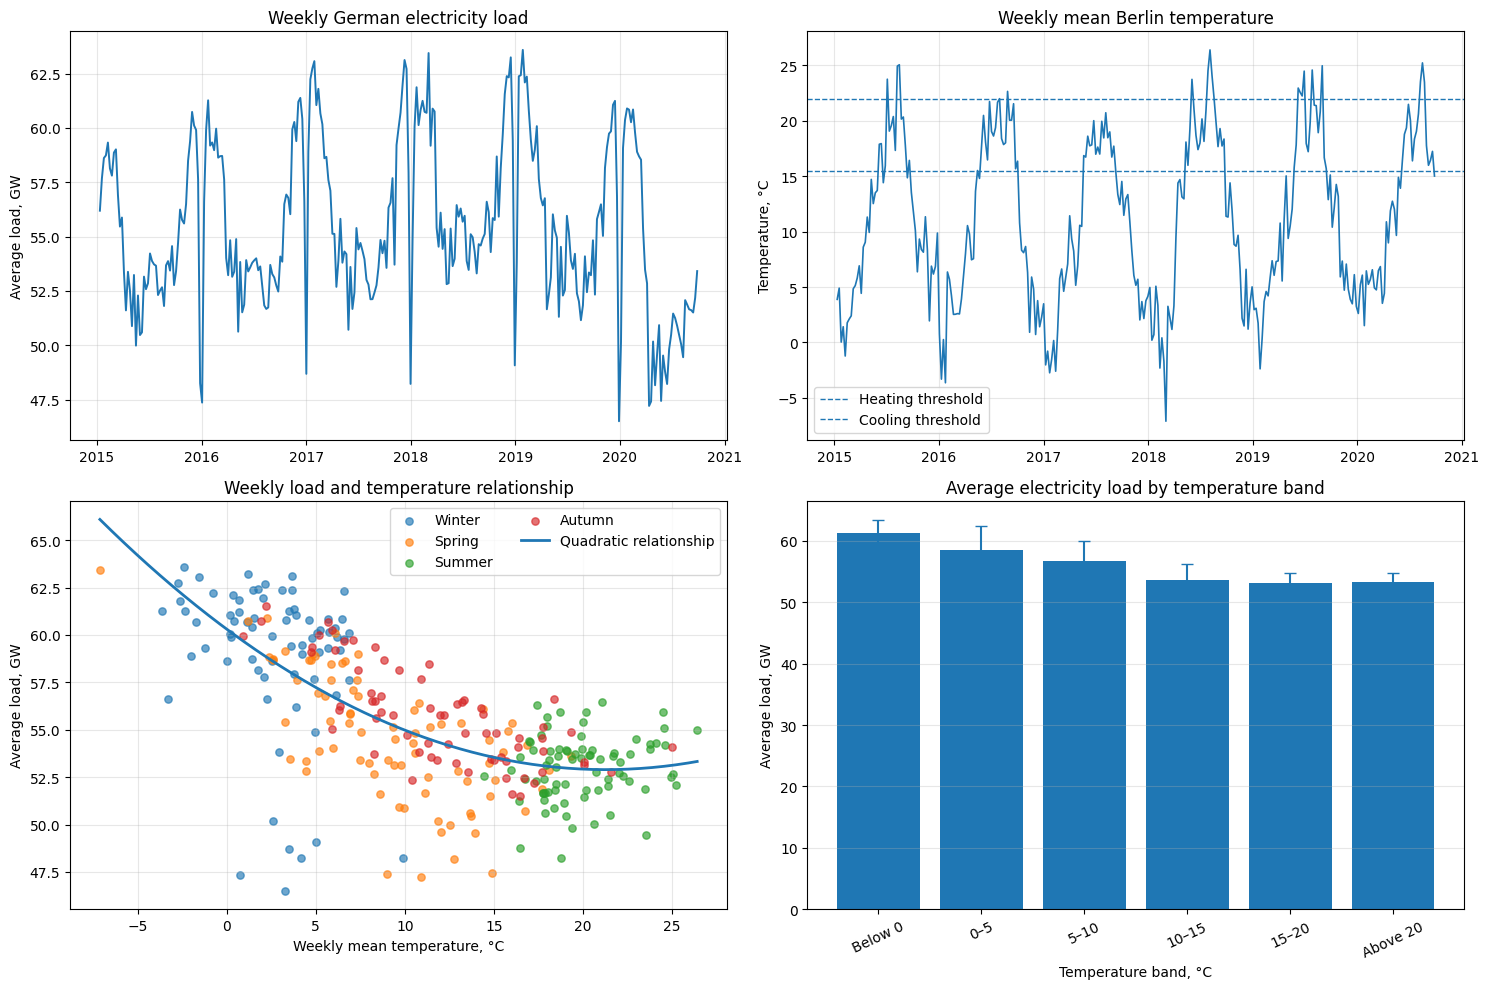

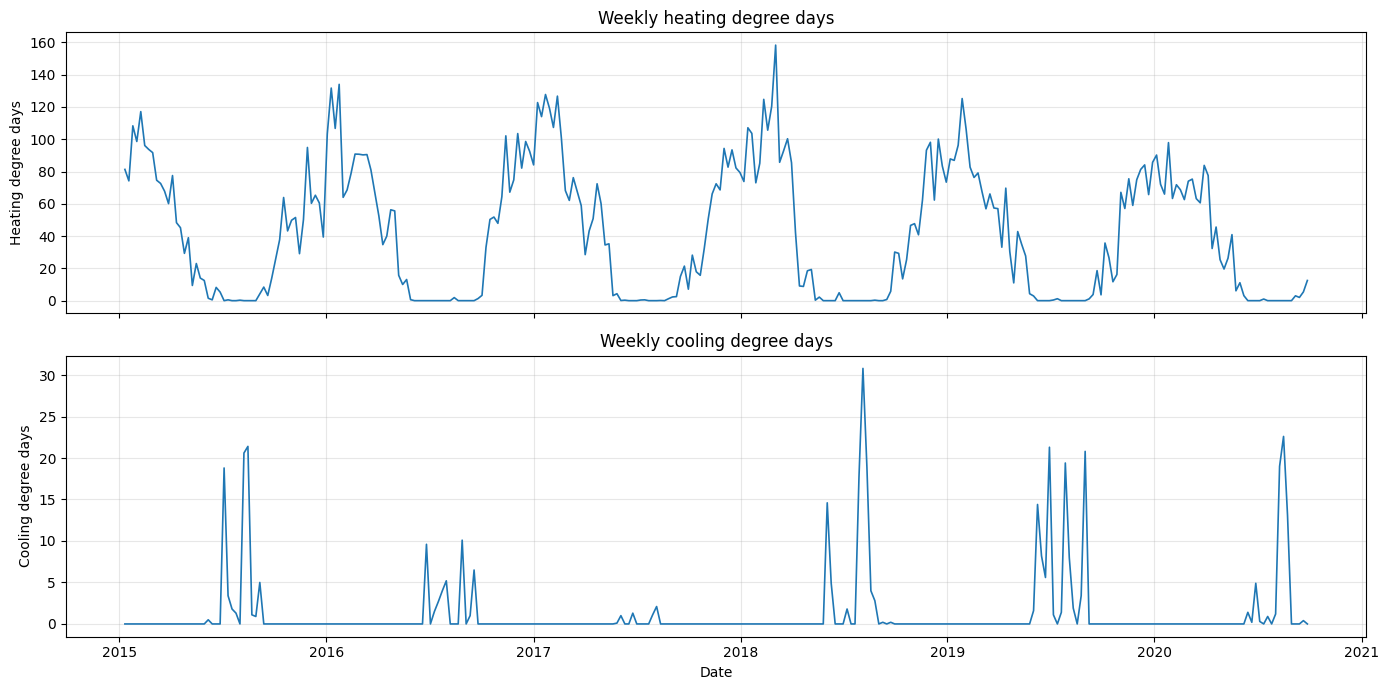

Average electricity demand within each temperature band:


,observation_count,average_load,standard_deviation,median_load
temperature_band,,,,
Below 0,12,61.242,2.090,61.532
0–5,64,58.565,3.868,59.400
5–10,68,56.696,3.244,56.880
10–15,48,53.587,2.644,54.039
15–20,68,53.075,1.690,53.404
Above 20,39,53.242,1.551,53.306


Correlation between load, weather and holiday variables:


,load_gw,temp_mean,heating_degree,cooling_degree,holiday_days
load_gw,1.000,-0.652,0.697,-0.162,-0.455
temp_mean,-0.652,1.000,-0.966,0.504,-0.077
heating_degree,0.697,-0.966,1.000,-0.312,0.033
cooling_degree,-0.162,0.504,-0.312,1.000,-0.101
holiday_days,-0.455,-0.077,0.033,-0.101,1.000


In [3]:
# =============================================================================
# CELL 3: WEATHER-FOCUSED EXPLORATORY DATA ANALYSIS
# =============================================================================
# This cell examines whether German weekly electricity demand appears to be
# related to Berlin temperature.
#
# The plots investigate:
# 1. Changes in electricity load over time.
# 2. Changes in Berlin temperature over time.
# 3. The potentially nonlinear relationship between temperature and load.
# 4. Average load across different temperature bands.
# 5. Heating and cooling degree-day patterns.
# =============================================================================


# -----------------------------------------------------------------------------
# ASSIGN EACH OBSERVATION TO A METEOROLOGICAL SEASON
# -----------------------------------------------------------------------------

season_mapping = {
    12: "Winter",
    1: "Winter",
    2: "Winter",

    3: "Spring",
    4: "Spring",
    5: "Spring",

    6: "Summer",
    7: "Summer",
    8: "Summer",

    9: "Autumn",
    10: "Autumn",
    11: "Autumn"
}

weekly_data["season"] = (
    weekly_data.index.month
    .map(season_mapping)
)


# -----------------------------------------------------------------------------
# COMBINED WEATHER-SENSITIVITY FIGURE
# -----------------------------------------------------------------------------
# The four related plots are placed in one figure so that the complete
# load-temperature relationship can be discussed together in the report.
# -----------------------------------------------------------------------------

figure, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 10)
)


# Plot 1: Weekly electricity demand.
axes[0, 0].plot(
    weekly_data.index,
    weekly_data["load_gw"],
    linewidth=1.4
)

axes[0, 0].set_title(
    "Weekly German electricity load"
)

axes[0, 0].set_ylabel(
    "Average load, GW"
)

axes[0, 0].grid(
    alpha=0.3
)


# Plot 2: Weekly Berlin temperature.
axes[0, 1].plot(
    weekly_data.index,
    weekly_data["temp_mean"],
    linewidth=1.2
)

axes[0, 1].axhline(
    HEATING_BASE,
    linestyle="--",
    linewidth=1,
    label="Heating threshold"
)

axes[0, 1].axhline(
    COOLING_BASE,
    linestyle="--",
    linewidth=1,
    label="Cooling threshold"
)

axes[0, 1].set_title(
    "Weekly mean Berlin temperature"
)

axes[0, 1].set_ylabel(
    "Temperature, °C"
)

axes[0, 1].legend()

axes[0, 1].grid(
    alpha=0.3
)


# Plot 3: Scatter plot of weekly temperature and electricity load.
# Separate seasonal labels help identify whether the relationship differs
# between winter, spring, summer and autumn.
for season_name in [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]:
    season_data = weekly_data[
        weekly_data["season"]
        == season_name
    ]

    axes[1, 0].scatter(
        season_data["temp_mean"],
        season_data["load_gw"],
        label=season_name,
        alpha=0.65,
        s=28
    )


# Fit a quadratic line because electricity demand may increase under both
# very cold and very warm conditions.
quadratic_coefficients = np.polyfit(
    weekly_data["temp_mean"],
    weekly_data["load_gw"],
    deg=2
)

temperature_grid = np.linspace(
    weekly_data["temp_mean"].min(),
    weekly_data["temp_mean"].max(),
    200
)

quadratic_values = np.polyval(
    quadratic_coefficients,
    temperature_grid
)

axes[1, 0].plot(
    temperature_grid,
    quadratic_values,
    linewidth=2,
    label="Quadratic relationship"
)

axes[1, 0].set_title(
    "Weekly load and temperature relationship"
)

axes[1, 0].set_xlabel(
    "Weekly mean temperature, °C"
)

axes[1, 0].set_ylabel(
    "Average load, GW"
)

axes[1, 0].legend(
    ncol=2
)

axes[1, 0].grid(
    alpha=0.3
)


# Plot 4: Group temperature into interpretable bands.
temperature_bins = [
    -np.inf,
    0,
    5,
    10,
    15,
    20,
    np.inf
]

temperature_band_labels = [
    "Below 0",
    "0–5",
    "5–10",
    "10–15",
    "15–20",
    "Above 20"
]

weekly_data["temperature_band"] = pd.cut(
    weekly_data["temp_mean"],
    bins=temperature_bins,
    labels=temperature_band_labels
)


# Calculate count, mean, standard deviation and median for each band.
temperature_band_summary = (
    weekly_data
    .groupby(
        "temperature_band",
        observed=False
    )["load_gw"]
    .agg(
        observation_count="count",
        average_load="mean",
        standard_deviation="std",
        median_load="median"
    )
)


# Display average load for each temperature band.
axes[1, 1].bar(
    temperature_band_summary.index.astype(
        str
    ),
    temperature_band_summary[
        "average_load"
    ]
)


# Add standard-deviation error bars to show variation inside each band.
axes[1, 1].errorbar(
    x=np.arange(
        len(
            temperature_band_summary
        )
    ),
    y=temperature_band_summary[
        "average_load"
    ],
    yerr=temperature_band_summary[
        "standard_deviation"
    ],
    fmt="none",
    capsize=4
)

axes[1, 1].set_title(
    "Average electricity load by temperature band"
)

axes[1, 1].set_xlabel(
    "Temperature band, °C"
)

axes[1, 1].set_ylabel(
    "Average load, GW"
)

axes[1, 1].tick_params(
    axis="x",
    rotation=25
)

axes[1, 1].grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

save_current_figure(
    "01_weather_sensitivity_analysis.png"
)


# -----------------------------------------------------------------------------
# DEGREE-DAY FIGURE
# -----------------------------------------------------------------------------
# Heating and cooling degree days are placed in separate panels because they
# have different ranges and represent different energy-demand mechanisms.
# -----------------------------------------------------------------------------

figure, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 7),
    sharex=True
)

axes[0].plot(
    weekly_data.index,
    weekly_data[
        "heating_degree"
    ],
    linewidth=1.2
)

axes[0].set_title(
    "Weekly heating degree days"
)

axes[0].set_ylabel(
    "Heating degree days"
)

axes[0].grid(
    alpha=0.3
)


axes[1].plot(
    weekly_data.index,
    weekly_data[
        "cooling_degree"
    ],
    linewidth=1.2
)

axes[1].set_title(
    "Weekly cooling degree days"
)

axes[1].set_xlabel(
    "Date"
)

axes[1].set_ylabel(
    "Cooling degree days"
)

axes[1].grid(
    alpha=0.3
)

plt.tight_layout()

save_current_figure(
    "02_heating_cooling_degree_days.png"
)


# -----------------------------------------------------------------------------
# DISPLAY SUPPORTING SUMMARY TABLES
# -----------------------------------------------------------------------------

print(
    "Average electricity demand "
    "within each temperature band:"
)

display(
    temperature_band_summary.round(3)
)


# Correlation is shown as an initial descriptive measure.
# It does not prove causation and may not capture nonlinear relationships.
weather_correlation_table = weekly_data[
    [
        "load_gw",
        "temp_mean",
        "heating_degree",
        "cooling_degree",
        "holiday_days"
    ]
].corr()

print(
    "Correlation between load, weather "
    "and holiday variables:"
)

display(
    weather_correlation_table.round(3)
)

Training period: 2015-01-11 to 2018-09-30
Number of training weeks: 195
Test period: 2018-10-07 to 2020-09-27
Number of test weeks: 104
Stationarity test results:


/tmp/ipykernel_5830/2514349346.py:286: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(
/tmp/ipykernel_5830/2514349346.py:286: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(
/tmp/ipykernel_5830/2514349346.py:286: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(
/tmp/ipykernel_5830/2514349346.py:286: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(


,Observations,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value
Series,,,,,
Original weekly load,195,-5.0030,0.0,0.1499,0.1
First difference,194,-5.5708,0.0,0.0406,0.1
Seasonal difference,143,-5.0395,0.0,0.0910,0.1
First and seasonal difference,142,-6.7279,0.0,0.0138,0.1


Lag-52 autocorrelation: 0.873
Initial seasonal differencing order: 1
Initial non-seasonal differencing order: 0


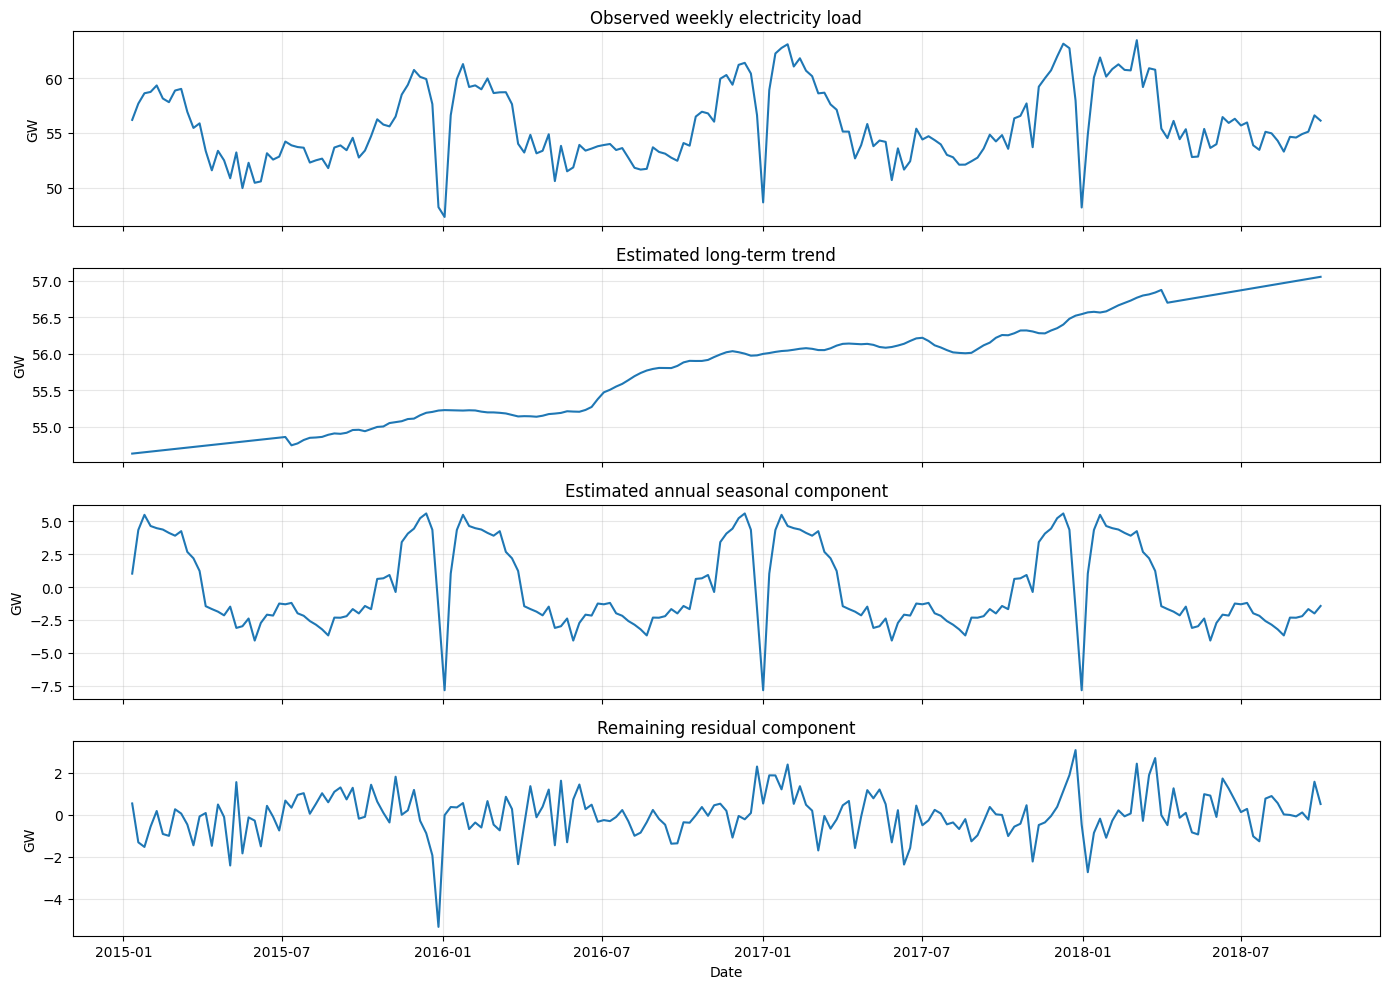

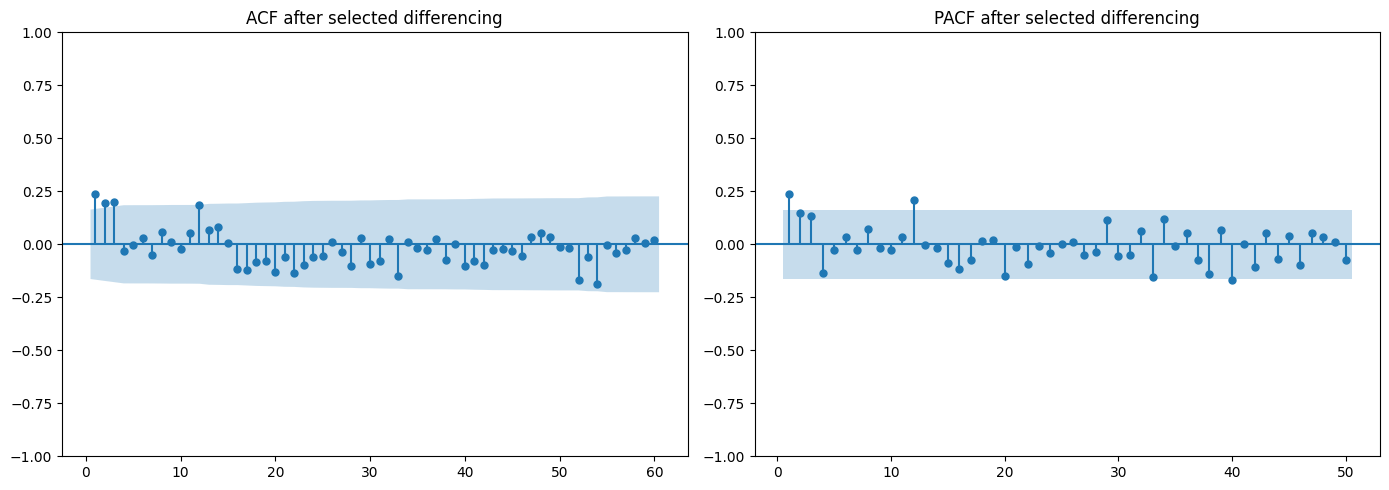

In [5]:
# =============================================================================
# CELL 4: CHRONOLOGICAL SPLIT, DECOMPOSITION AND STATIONARITY ANALYSIS
# =============================================================================
# This cell reserves the final 104 weeks as the test set.
#
# All stationarity analysis is performed only on training data. This prevents
# information from the future test period from influencing modelling choices.
#
# The cell then:
# 1. Examines trend and annual seasonality.
# 2. Applies ADF and KPSS tests.
# 3. Tests first and seasonal differencing.
# 4. Produces ACF and PACF plots for model identification.
# =============================================================================


# -----------------------------------------------------------------------------
# CHRONOLOGICAL TRAIN-TEST SPLIT
# -----------------------------------------------------------------------------
# The final 104 weeks are kept as an untouched two-year test period.
# No random splitting or shuffling is used for time-series data.
# -----------------------------------------------------------------------------

train_data = weekly_data.iloc[
    :-TEST_WEEKS
].copy()

test_data = weekly_data.iloc[
    -TEST_WEEKS:
].copy()

y_train = train_data[
    "load_gw"
].copy()

y_test = test_data[
    "load_gw"
].copy()


print(
    "Training period:",
    y_train.index.min().date(),
    "to",
    y_train.index.max().date()
)

print(
    "Number of training weeks:",
    len(y_train)
)

print(
    "Test period:",
    y_test.index.min().date(),
    "to",
    y_test.index.max().date()
)

print(
    "Number of test weeks:",
    len(y_test)
)


# -----------------------------------------------------------------------------
# CREATE DIFFERENCED VERSIONS OF THE TRAINING SERIES
# -----------------------------------------------------------------------------

# First differencing removes non-seasonal changes in the level of the series.
first_difference = (
    y_train
    .diff()
    .dropna()
)


# Seasonal differencing compares each week with the corresponding week
# one year earlier.
seasonal_difference = (
    y_train
    .diff(SEASONAL_PERIOD)
    .dropna()
)


# Combined differencing applies both first and seasonal differences.
combined_difference = (
    y_train
    .diff()
    .diff(SEASONAL_PERIOD)
    .dropna()
)


# -----------------------------------------------------------------------------
# APPLY ADF AND KPSS TESTS TO EACH VERSION
# -----------------------------------------------------------------------------

stationarity_results = pd.DataFrame(
    [
        run_stationarity_tests(
            y_train,
            "Original weekly load"
        ),

        run_stationarity_tests(
            first_difference,
            "First difference"
        ),

        run_stationarity_tests(
            seasonal_difference,
            "Seasonal difference"
        ),

        run_stationarity_tests(
            combined_difference,
            "First and seasonal difference"
        )
    ]
).set_index("Series")


print(
    "Stationarity test results:"
)

display(
    stationarity_results.round(4)
)


# -----------------------------------------------------------------------------
# INITIAL DIFFERENCING GUIDANCE
# -----------------------------------------------------------------------------
# Strong lag-52 autocorrelation indicates that the same week in consecutive
# years tends to be related, supporting annual seasonal differencing.
# -----------------------------------------------------------------------------

lag_52_autocorrelation = (
    y_train.autocorr(
        lag=SEASONAL_PERIOD
    )
)

SELECTED_D = (
    1
    if abs(
        lag_52_autocorrelation
    ) >= 0.30
    else 0
)


# Non-seasonal first differencing is considered if the original training
# series fails the ADF test at the 5% significance level.
DIAGNOSTIC_d = (
    1
    if stationarity_results.loc[
        "Original weekly load",
        "ADF p-value"
    ] > 0.05
    else 0
)


print(
    "Lag-52 autocorrelation:",
    round(
        lag_52_autocorrelation,
        3
    )
)

print(
    "Initial seasonal differencing order:",
    SELECTED_D
)

print(
    "Initial non-seasonal differencing order:",
    DIAGNOSTIC_d
)


# -----------------------------------------------------------------------------
# SEASONAL DECOMPOSITION
# -----------------------------------------------------------------------------
# Additive decomposition separates the series into:
# - Observed values
# - Long-term trend
# - Repeating annual seasonal component
# - Remaining unexplained residual component
# -----------------------------------------------------------------------------

decomposition = seasonal_decompose(
    y_train,
    model="additive",
    period=SEASONAL_PERIOD,
    extrapolate_trend="freq"
)

figure, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(14, 10),
    sharex=True
)

axes[0].plot(
    decomposition.observed
)

axes[0].set_title(
    "Observed weekly electricity load"
)

axes[0].set_ylabel("GW")


axes[1].plot(
    decomposition.trend
)

axes[1].set_title(
    "Estimated long-term trend"
)

axes[1].set_ylabel("GW")


axes[2].plot(
    decomposition.seasonal
)

axes[2].set_title(
    "Estimated annual seasonal component"
)

axes[2].set_ylabel("GW")


axes[3].plot(
    decomposition.resid
)

axes[3].set_title(
    "Remaining residual component"
)

axes[3].set_ylabel("GW")

axes[3].set_xlabel(
    "Date"
)

for axis in axes:
    axis.grid(
        alpha=0.3
    )

plt.tight_layout()

save_current_figure(
    "03_weekly_load_decomposition.png"
)


# -----------------------------------------------------------------------------
# SELECT THE SERIES USED FOR ACF AND PACF DIAGNOSTICS
# -----------------------------------------------------------------------------

diagnostic_series = y_train.copy()

if SELECTED_D == 1:
    diagnostic_series = (
        diagnostic_series
        .diff(SEASONAL_PERIOD)
    )

if DIAGNOSTIC_d == 1:
    diagnostic_series = (
        diagnostic_series
        .diff()
    )

diagnostic_series = (
    diagnostic_series
    .dropna()
)


# -----------------------------------------------------------------------------
# ACF AND PACF
# -----------------------------------------------------------------------------
# ACF helps identify moving-average behaviour.
# PACF helps identify autoregressive behaviour.
# These plots support the SARIMA parameter search and interpretation.
# -----------------------------------------------------------------------------

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5)
)

plot_acf(
    diagnostic_series,
    lags=min(
        60,
        len(diagnostic_series) // 2 - 1
    ),
    ax=axes[0],
    zero=False
)

axes[0].set_title(
    "ACF after selected differencing"
)


plot_pacf(
    diagnostic_series,
    lags=min(
        50,
        len(diagnostic_series) // 2 - 1
    ),
    ax=axes[1],
    zero=False,
    method="ywm"
)

axes[1].set_title(
    "PACF after selected differencing"
)

plt.tight_layout()

save_current_figure(
    "04_acf_pacf_after_differencing.png"
)

Benchmark forecasting results:


,Model,Forecast type,MAE,RMSE,MASE,sMAPE,Bias
0,Mean,Operational,3.790,4.402,2.805,6.874,0.561
1,Naive,Operational,3.858,4.476,2.856,6.995,0.985
2,Seasonal naive,Operational,2.288,2.988,1.694,4.207,1.748
3,Drift,Operational,3.851,4.466,2.850,6.982,0.966


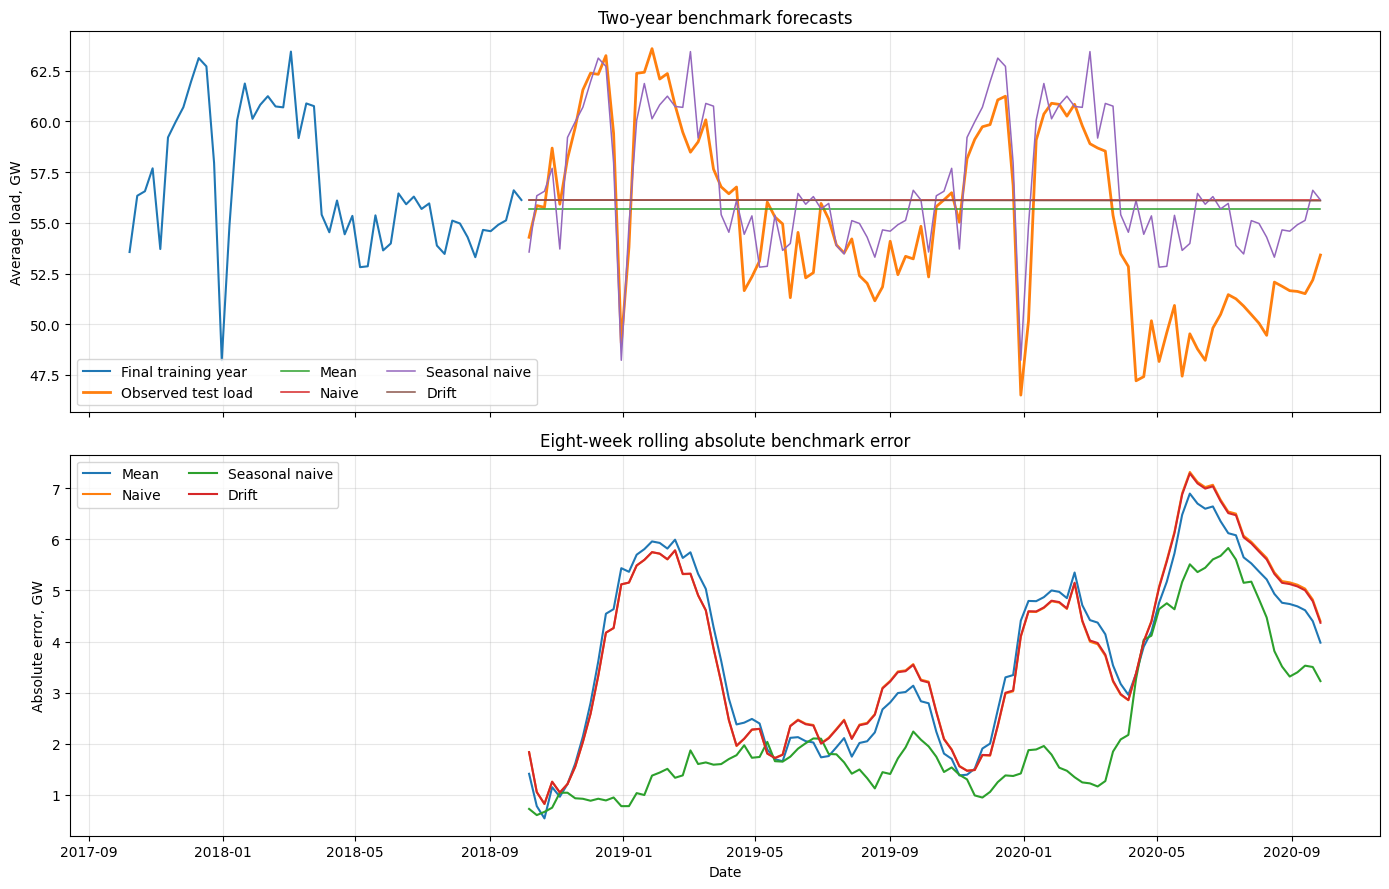

In [6]:
# =============================================================================
# CELL 5: BENCHMARK FORECASTING MODELS
# =============================================================================
# This cell creates the four compulsory benchmark forecasts:
# 1. Mean
# 2. Naive
# 3. Seasonal naive
# 4. Drift
#
# All four models forecast the complete 104-week test period from one fixed
# forecast origin. Actual test observations are never inserted into the
# forecasting history.
# =============================================================================


# Lists and dictionaries used to store model results and predictions.
results = []
forecast_store = {}

forecast_horizon = len(
    y_test
)


# -----------------------------------------------------------------------------
# MEAN FORECAST
# -----------------------------------------------------------------------------
# Every future week is forecast as the average training-period load.
# -----------------------------------------------------------------------------

mean_forecast = pd.Series(
    data=y_train.mean(),
    index=y_test.index,
    name="Mean"
)


# -----------------------------------------------------------------------------
# NAIVE FORECAST
# -----------------------------------------------------------------------------
# Every future week is forecast as the final training observation.
# -----------------------------------------------------------------------------

naive_forecast = pd.Series(
    data=y_train.iloc[-1],
    index=y_test.index,
    name="Naive"
)


# -----------------------------------------------------------------------------
# SEASONAL-NAIVE FORECAST
# -----------------------------------------------------------------------------
# The final 52 weeks of training data are repeated across the two-year test
# horizon. This represents the expectation that each week resembles the
# corresponding week one year earlier.
#
# Test observations are not used to update this forecast.
# -----------------------------------------------------------------------------

final_training_year = (
    y_train
    .iloc[-SEASONAL_PERIOD:]
    .to_numpy()
)

seasonal_naive_values = np.resize(
    final_training_year,
    forecast_horizon
)

seasonal_naive_forecast = pd.Series(
    seasonal_naive_values,
    index=y_test.index,
    name="Seasonal naive"
)


# -----------------------------------------------------------------------------
# DRIFT FORECAST
# -----------------------------------------------------------------------------
# Drift extends the average change between the first and final training
# observations into the future.
# -----------------------------------------------------------------------------

average_weekly_drift = (
    y_train.iloc[-1]
    - y_train.iloc[0]
) / (
    len(y_train) - 1
)

drift_values = (
    y_train.iloc[-1]
    + average_weekly_drift
    * np.arange(
        1,
        forecast_horizon + 1
    )
)

drift_forecast = pd.Series(
    drift_values,
    index=y_test.index,
    name="Drift"
)


# Store all benchmark forecasts in one dictionary.
benchmark_forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal naive": seasonal_naive_forecast,
    "Drift": drift_forecast
}


# -----------------------------------------------------------------------------
# EVALUATE EACH BENCHMARK
# -----------------------------------------------------------------------------

for model_name, prediction in benchmark_forecasts.items():

    model_metrics = evaluate_forecast(
        model_name=model_name,
        y_true=y_test,
        y_pred=prediction,
        y_train=y_train,
        forecast_type="Operational"
    )

    results.append(
        model_metrics
    )

    forecast_store[
        model_name
    ] = prediction


benchmark_results = pd.DataFrame(
    results
)


print(
    "Benchmark forecasting results:"
)

display(
    benchmark_results.round(3)
)


# -----------------------------------------------------------------------------
# COMBINED BENCHMARK FORECAST AND ERROR FIGURE
# -----------------------------------------------------------------------------

figure, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 9),
    sharex=True
)


# Upper panel: actual test load and benchmark forecasts.
axes[0].plot(
    y_train.index[-52:],
    y_train.iloc[-52:],
    label="Final training year",
    linewidth=1.5
)

axes[0].plot(
    y_test.index,
    y_test,
    label="Observed test load",
    linewidth=2
)

for model_name, prediction in benchmark_forecasts.items():

    axes[0].plot(
        prediction.index,
        prediction,
        label=model_name,
        linewidth=1.1
    )

axes[0].set_title(
    "Two-year benchmark forecasts"
)

axes[0].set_ylabel(
    "Average load, GW"
)

axes[0].legend(
    ncol=3
)

axes[0].grid(
    alpha=0.3
)


# Lower panel: eight-week rolling absolute errors.
# Rolling errors make persistent forecasting weaknesses easier to identify
# than a single overall RMSE value.
for model_name, prediction in benchmark_forecasts.items():

    rolling_absolute_error = (
        prediction - y_test
    ).abs().rolling(
        window=8,
        min_periods=1
    ).mean()

    axes[1].plot(
        rolling_absolute_error.index,
        rolling_absolute_error,
        label=model_name
    )

axes[1].set_title(
    "Eight-week rolling absolute benchmark error"
)

axes[1].set_ylabel(
    "Absolute error, GW"
)

axes[1].set_xlabel(
    "Date"
)

axes[1].legend(
    ncol=2
)

axes[1].grid(
    alpha=0.3
)

plt.tight_layout()

save_current_figure(
    "05_benchmark_forecast_comparison.png"
)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Required p-d-q combinations screened: 147
Best non-seasonal SARIMA order: (1, 1, 2)
Best seasonal SARIMA order: (0, 1, 1, 52)
Total SARIMA search time in minutes: 1.96
Top preliminary p-d-q combinations:


,p,d,q,P,D,Q,s,Screening AIC,Screening BIC
0,0,1,6,0,1,0,52,437.092,456.122
1,1,1,6,0,1,0,52,437.637,459.385
2,0,1,5,0,1,0,52,438.330,454.694
3,1,0,6,0,1,0,52,438.868,460.687
4,0,1,4,0,1,0,52,439.143,452.824
5,1,1,5,0,1,0,52,439.155,458.247
6,2,1,6,0,1,0,52,439.207,463.673
7,0,0,6,0,1,0,52,439.934,459.026
8,1,1,4,0,1,0,52,440.232,456.649
9,2,1,5,0,1,0,52,440.456,462.276


Maximum-likelihood non-seasonal comparison:


,p,d,q,P,D,Q,s,AIC,BIC,Converged
0,1,1,2,0,1,0,52,537.772,549.510,True
1,0,1,2,0,1,0,52,541.667,550.470,True
2,1,0,2,0,1,0,52,543.841,555.608,True
3,1,1,1,0,1,0,52,544.032,552.857,True
4,0,1,1,0,1,0,52,544.483,550.366,True
5,2,0,2,0,1,0,52,545.632,560.341,True


Seasonal-order comparison:


,p,d,q,P,D,Q,s,AIC,BIC,Converged
0,1,1,2,0,1,1,52,311.034,323.363,True
1,1,1,2,1,1,1,52,315.902,330.697,True
2,1,1,2,1,1,0,52,329.429,341.872,True
3,1,1,2,0,1,0,52,537.772,549.510,True
4,1,1,2,1,0,0,52,540.184,554.928,True
5,1,1,2,0,0,0,52,848.301,861.310,True


Ljung-Box residual test:


,lb_stat,lb_pvalue
10,12.3040,0.2652
26,22.2203,0.6766
49,25.5489,0.9977


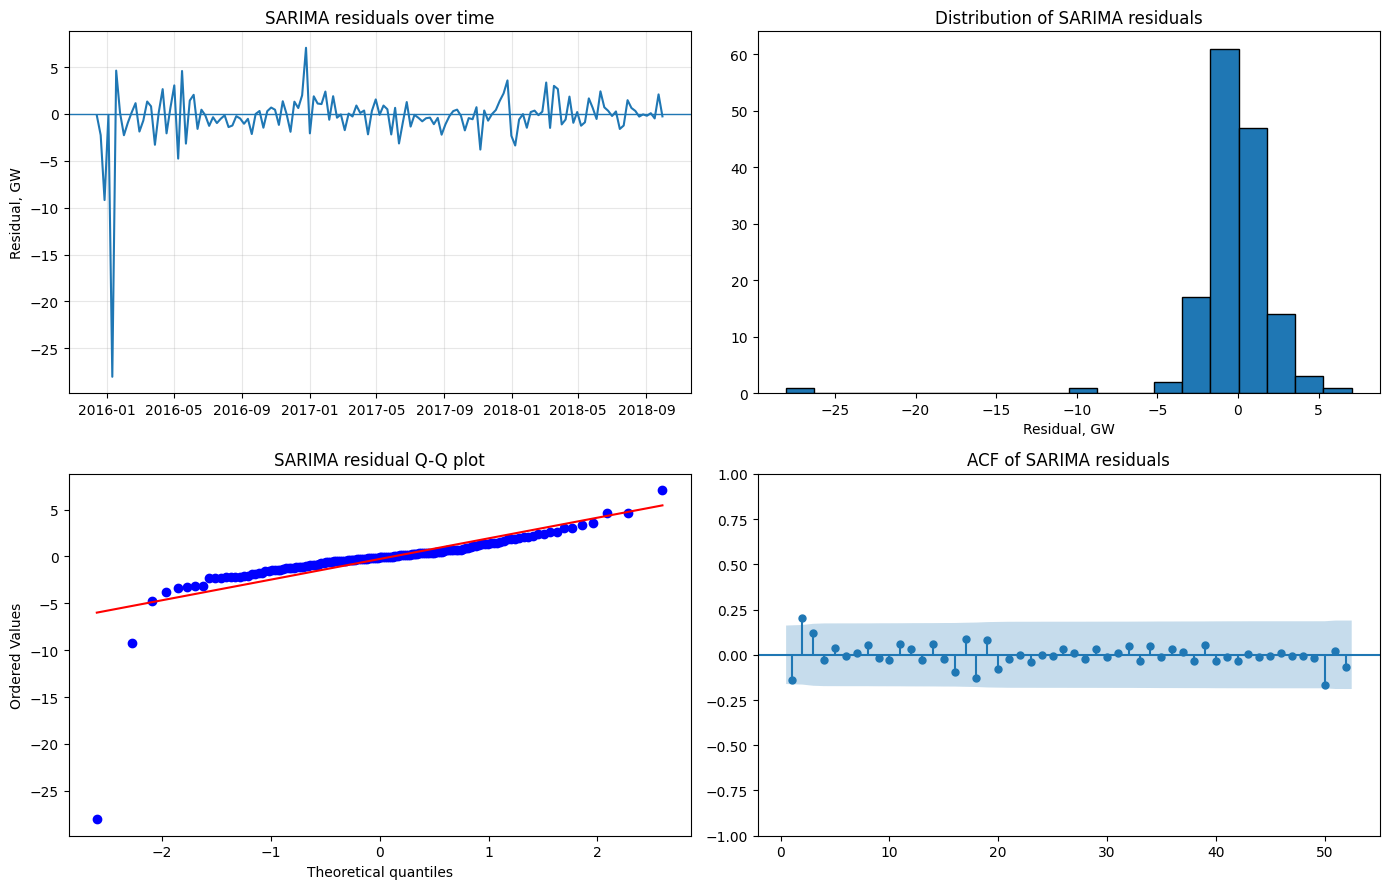

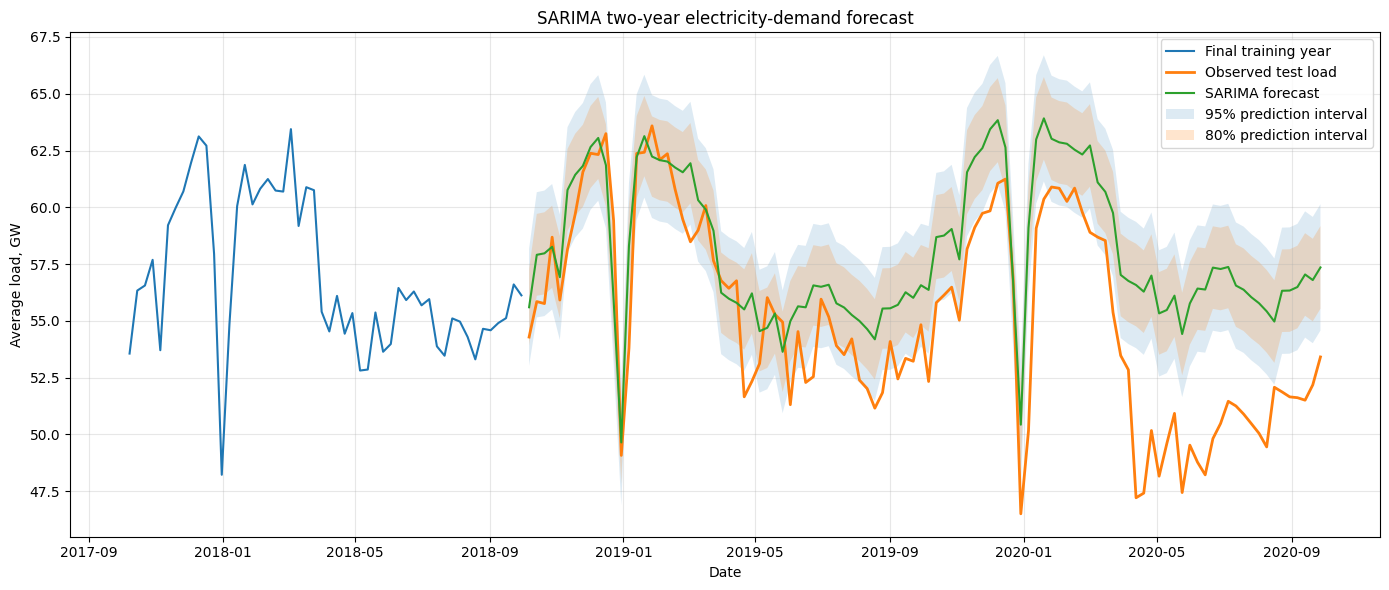

In [7]:
# =============================================================================
# CELL 6: SARIMA PARAMETER SEARCH, DIAGNOSTICS AND FORECAST
# =============================================================================
# This cell builds the load-only statistical model.
#
# The assignment requires all combinations of:
# p = 0 to 6
# d = 0 to 2
# q = 0 to 6
#
# This gives 147 non-seasonal combinations.
#
# To control execution time:
# 1. All 147 combinations are screened using Hannan-Rissanen estimation.
# 2. The strongest parsimonious candidates are refitted using SARIMA maximum
#    likelihood.
# 3. A compact seasonal grid is then tested using AIC.
# =============================================================================


# -----------------------------------------------------------------------------
# PREPARE A SERIES FOR FAST NON-SEASONAL PARAMETER SCREENING
# -----------------------------------------------------------------------------

def prepare_screening_series(
    series,
    d,
    D,
    seasonal_period
):
    """
    Apply the required non-seasonal and seasonal differences before
    preliminary ARMA screening.
    """
    transformed_series = series.copy()

    if D == 1:
        transformed_series = (
            transformed_series
            .diff(seasonal_period)
        )

    for _ in range(d):
        transformed_series = (
            transformed_series
            .diff()
        )

    return transformed_series.dropna()


def screen_pdq_candidate(
    p,
    d,
    q,
    D
):
    """
    Screen one p-d-q combination using the Hannan-Rissanen estimator.

    This is faster than fitting 147 full seasonal maximum-likelihood models.
    It is used only for screening. Final selected candidates are later
    refitted using SARIMA maximum likelihood.
    """
    try:
        transformed_series = (
            prepare_screening_series(
                series=y_train,
                d=d,
                D=D,
                seasonal_period=SEASONAL_PERIOD
            )
        )

        _, screening_details = (
            hannan_rissanen(
                transformed_series.to_numpy(),
                ar_order=p,
                ma_order=q,
                demean=False,
                unbiased=False
            )
        )

        residuals = np.asarray(
            screening_details.resid,
            dtype=float
        )

        residual_variance = np.mean(
            residuals ** 2
        )

        observation_count = len(
            residuals
        )

        parameter_count = p + q + 1

        approximate_log_likelihood = (
            -0.5
            * observation_count
            * (
                np.log(2 * np.pi)
                + 1
                + np.log(
                    residual_variance
                )
            )
        )

        screening_aic = (
            2 * parameter_count
            - 2 * approximate_log_likelihood
        )

        screening_bic = (
            np.log(observation_count)
            * parameter_count
            - 2 * approximate_log_likelihood
        )

        return {
            "p": p,
            "d": d,
            "q": q,
            "P": 0,
            "D": D,
            "Q": 0,
            "s": SEASONAL_PERIOD,
            "Screening AIC": screening_aic,
            "Screening BIC": screening_bic
        }

    except Exception:
        # Invalid or numerically unstable combinations are skipped.
        return None


# -----------------------------------------------------------------------------
# FULL SARIMA MAXIMUM-LIKELIHOOD FITTING FUNCTION
# -----------------------------------------------------------------------------

def fit_sarima_candidate(
    order,
    seasonal_order,
    maximum_iterations=80
):
    """
    Fit one SARIMA model and return model-selection information.

    enforce_stationarity=False and enforce_invertibility=False allow a wider
    parameter search, while residual diagnostics are later used to assess
    whether the selected model is acceptable.
    """
    try:
        if (
            order[1] == 0
            and seasonal_order[1] == 0
        ):
            trend_setting = "c"
        else:
            trend_setting = "n"

        sarima_model = SARIMAX(
            y_train,
            order=order,
            seasonal_order=seasonal_order,
            trend=trend_setting,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = sarima_model.fit(
            disp=False,
            maxiter=maximum_iterations
        )

        return {
            "p": order[0],
            "d": order[1],
            "q": order[2],
            "P": seasonal_order[0],
            "D": seasonal_order[1],
            "Q": seasonal_order[2],
            "s": seasonal_order[3],
            "AIC": fitted_model.aic,
            "BIC": fitted_model.bic,
            "Converged": bool(
                fitted_model.mle_retvals.get(
                    "converged",
                    True
                )
            ),
            "Fitted model": fitted_model
        }

    except Exception:
        return None


# -----------------------------------------------------------------------------
# SCREEN ALL REQUIRED P-D-Q COMBINATIONS
# -----------------------------------------------------------------------------

search_start_time = time.time()

initial_seasonal_difference = SELECTED_D

all_pdq_combinations = list(
    itertools.product(
        range(7),
        range(3),
        range(7)
    )
)

screening_results = []

for p, d, q in all_pdq_combinations:

    candidate_result = (
        screen_pdq_candidate(
            p=p,
            d=d,
            q=q,
            D=initial_seasonal_difference
        )
    )

    if candidate_result is not None:
        screening_results.append(
            candidate_result
        )


pdq_screening_table = (
    pd.DataFrame(
        screening_results
    )
    .sort_values(
        "Screening AIC"
    )
    .reset_index(drop=True)
)

if pdq_screening_table.empty:
    raise RuntimeError(
        "No p-d-q candidate completed "
        "the screening stage."
    )


# -----------------------------------------------------------------------------
# SELECT PARSIMONIOUS CANDIDATES FOR FULL REFITTING
# -----------------------------------------------------------------------------
# Lower-order models are prioritised because the weekly training set is
# relatively small. Very high-order models may overfit or fail to converge.
# -----------------------------------------------------------------------------

parsimonious_candidates = (
    pdq_screening_table[
        (pdq_screening_table["p"] <= 2)
        & (pdq_screening_table["q"] <= 2)
    ]
    .copy()
)

shortlisted_orders = []

for order_values in (
    parsimonious_candidates[
        ["p", "d", "q"]
    ]
    .astype(int)
    .to_numpy()
):
    order_tuple = tuple(
        order_values
    )

    if (
        order_tuple
        not in shortlisted_orders
    ):
        shortlisted_orders.append(
            order_tuple
        )

    if len(shortlisted_orders) == 6:
        break


# -----------------------------------------------------------------------------
# REFIT SHORTLISTED NON-SEASONAL ORDERS WITH MAXIMUM LIKELIHOOD
# -----------------------------------------------------------------------------

nonseasonal_refit_results = []

for order_tuple in shortlisted_orders:

    fitted_candidate = fit_sarima_candidate(
        order=order_tuple,
        seasonal_order=(
            0,
            initial_seasonal_difference,
            0,
            SEASONAL_PERIOD
        ),
        maximum_iterations=40
    )

    if fitted_candidate is not None:
        nonseasonal_refit_results.append(
            fitted_candidate
        )


if not nonseasonal_refit_results:
    raise RuntimeError(
        "The shortlisted SARIMA models "
        "could not be fitted."
    )


nonseasonal_refit_table = pd.DataFrame(
    [
        {
            key: value
            for key, value in result.items()
            if key != "Fitted model"
        }
        for result in nonseasonal_refit_results
    ]
)


# Prefer converged models when selecting the best order.
converged_nonseasonal = (
    nonseasonal_refit_table[
        nonseasonal_refit_table[
            "Converged"
        ]
    ]
)

if converged_nonseasonal.empty:
    nonseasonal_selection_table = (
        nonseasonal_refit_table.copy()
    )
else:
    nonseasonal_selection_table = (
        converged_nonseasonal.copy()
    )

nonseasonal_selection_table = (
    nonseasonal_selection_table
    .sort_values("AIC")
    .reset_index(drop=True)
)


best_nonseasonal_order = tuple(
    nonseasonal_selection_table.loc[
        0,
        ["p", "d", "q"]
    ]
    .astype(int)
    .tolist()
)


# -----------------------------------------------------------------------------
# TEST A COMPACT SEASONAL PARAMETER GRID
# -----------------------------------------------------------------------------
# The assignment gives explicit ranges for p, d and q but does not clearly
# specify complete ranges for P, D and Q. A documented grid containing
# 0 and 1 is used to control computation while examining annual seasonality.
# -----------------------------------------------------------------------------

seasonal_parameter_combinations = list(
    itertools.product(
        [0, 1],
        [0, 1],
        [0, 1]
    )
)

seasonal_model_results = []

for P, D, Q in seasonal_parameter_combinations:

    seasonal_candidate = (
        fit_sarima_candidate(
            order=best_nonseasonal_order,
            seasonal_order=(
                P,
                D,
                Q,
                SEASONAL_PERIOD
            ),
            maximum_iterations=50
        )
    )

    if seasonal_candidate is not None:
        seasonal_model_results.append(
            seasonal_candidate
        )


seasonal_model_table = pd.DataFrame(
    [
        {
            key: value
            for key, value in result.items()
            if key != "Fitted model"
        }
        for result in seasonal_model_results
    ]
)

if seasonal_model_table.empty:
    raise RuntimeError(
        "No seasonal SARIMA candidate "
        "could be fitted."
    )


converged_seasonal_models = (
    seasonal_model_table[
        seasonal_model_table[
            "Converged"
        ]
    ]
)

if converged_seasonal_models.empty:
    seasonal_selection_table = (
        seasonal_model_table.copy()
    )
else:
    seasonal_selection_table = (
        converged_seasonal_models.copy()
    )

seasonal_selection_table = (
    seasonal_selection_table
    .sort_values("AIC")
    .reset_index(drop=True)
)


best_seasonal_order = tuple(
    seasonal_selection_table.loc[
        0,
        ["P", "D", "Q", "s"]
    ]
    .astype(int)
    .tolist()
)


# -----------------------------------------------------------------------------
# FIT THE FINAL SELECTED SARIMA MODEL
# -----------------------------------------------------------------------------

final_sarima_result = (
    fit_sarima_candidate(
        order=best_nonseasonal_order,
        seasonal_order=best_seasonal_order,
        maximum_iterations=80
    )
)

if final_sarima_result is None:
    raise RuntimeError(
        "The selected SARIMA model "
        "could not be fitted."
    )

sarima_fit = final_sarima_result[
    "Fitted model"
]


# Save search tables for the report and repository.
pdq_screening_table.to_csv(
    TABLE_DIR
    / "sarima_complete_pdq_screening.csv",
    index=False
)

nonseasonal_refit_table.to_csv(
    TABLE_DIR
    / "sarima_shortlisted_models.csv",
    index=False
)

seasonal_model_table.to_csv(
    TABLE_DIR
    / "sarima_seasonal_models.csv",
    index=False
)


print(
    "Required p-d-q combinations screened:",
    len(all_pdq_combinations)
)

print(
    "Best non-seasonal SARIMA order:",
    best_nonseasonal_order
)

print(
    "Best seasonal SARIMA order:",
    best_seasonal_order
)

print(
    "Total SARIMA search time in minutes:",
    round(
        (
            time.time()
            - search_start_time
        ) / 60,
        2
    )
)


print(
    "Top preliminary p-d-q combinations:"
)

display(
    pdq_screening_table
    .head(10)
    .round(3)
)


print(
    "Maximum-likelihood non-seasonal comparison:"
)

display(
    nonseasonal_selection_table
    .head(10)
    .round(3)
)


print(
    "Seasonal-order comparison:"
)

display(
    seasonal_selection_table.round(3)
)


# -----------------------------------------------------------------------------
# GENERATE THE 104-WEEK SARIMA FORECAST
# -----------------------------------------------------------------------------

sarima_forecast_object = (
    sarima_fit
    .get_forecast(
        steps=len(y_test)
    )
)

sarima_forecast = (
    sarima_forecast_object
    .predicted_mean
)

sarima_forecast.index = (
    y_test.index
)


# Produce 80% and 95% prediction intervals.
sarima_interval_80 = (
    sarima_forecast_object
    .conf_int(alpha=0.20)
)

sarima_interval_95 = (
    sarima_forecast_object
    .conf_int(alpha=0.05)
)

sarima_interval_80.index = y_test.index
sarima_interval_95.index = y_test.index


# Evaluate the point forecast.
sarima_metrics = evaluate_forecast(
    model_name="SARIMA",
    y_true=y_test,
    y_pred=sarima_forecast,
    y_train=y_train,
    forecast_type="Operational"
)


# Calculate the percentage of actual observations falling inside the interval.
sarima_metrics[
    "95% interval coverage"
] = float(
    (
        (
            y_test
            >= sarima_interval_95.iloc[
                :, 0
            ]
        )
        &
        (
            y_test
            <= sarima_interval_95.iloc[
                :, 1
            ]
        )
    ).mean()
)


# Average interval width represents forecast uncertainty.
sarima_metrics[
    "Average 95% interval width"
] = float(
    (
        sarima_interval_95.iloc[:, 1]
        - sarima_interval_95.iloc[:, 0]
    ).mean()
)


results.append(
    sarima_metrics
)

forecast_store[
    "SARIMA"
] = sarima_forecast


# -----------------------------------------------------------------------------
# RESIDUAL DIAGNOSTICS
# -----------------------------------------------------------------------------
# A good SARIMA model should leave residuals that:
# - Are centred around zero
# - Have no obvious trend or seasonality
# - Contain little remaining autocorrelation
# - Are reasonably close to a normal distribution
# -----------------------------------------------------------------------------

sarima_residuals = pd.Series(
    sarima_fit.resid,
    index=y_train.index
)

sarima_residuals = (
    sarima_residuals
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna()
)


# Remove the initial residual section affected by model initialisation.
initial_residuals_to_remove = min(
    SEASONAL_PERIOD,
    max(
        0,
        len(sarima_residuals) // 4
    )
)

sarima_residuals = (
    sarima_residuals.iloc[
        initial_residuals_to_remove:
    ]
)


# Ljung-Box tests whether groups of residual autocorrelations are jointly zero.
ljung_box_results = acorr_ljungbox(
    sarima_residuals,
    lags=[
        10,
        26,
        min(
            52,
            len(sarima_residuals) // 3
        )
    ],
    return_df=True
)

print(
    "Ljung-Box residual test:"
)

display(
    ljung_box_results.round(4)
)


# -----------------------------------------------------------------------------
# COMBINED RESIDUAL-DIAGNOSTIC FIGURE
# -----------------------------------------------------------------------------

figure, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 9)
)


# Residual sequence through time.
axes[0, 0].plot(
    sarima_residuals.index,
    sarima_residuals
)

axes[0, 0].axhline(
    0,
    linewidth=1
)

axes[0, 0].set_title(
    "SARIMA residuals over time"
)

axes[0, 0].set_ylabel(
    "Residual, GW"
)

axes[0, 0].grid(
    alpha=0.3
)


# Residual distribution.
axes[0, 1].hist(
    sarima_residuals,
    bins=20,
    edgecolor="black"
)

axes[0, 1].set_title(
    "Distribution of SARIMA residuals"
)

axes[0, 1].set_xlabel(
    "Residual, GW"
)


# Normal Q-Q plot.
stats.probplot(
    sarima_residuals,
    dist="norm",
    plot=axes[1, 0]
)

axes[1, 0].set_title(
    "SARIMA residual Q-Q plot"
)


# Residual autocorrelation.
plot_acf(
    sarima_residuals,
    lags=min(
        52,
        len(sarima_residuals) // 2 - 1
    ),
    ax=axes[1, 1],
    zero=False
)

axes[1, 1].set_title(
    "ACF of SARIMA residuals"
)

plt.tight_layout()

save_current_figure(
    "06_sarima_residual_diagnostics.png"
)


# -----------------------------------------------------------------------------
# SARIMA FORECAST WITH CONFIDENCE INTERVALS
# -----------------------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(14, 6)
)

axis.plot(
    y_train.index[-52:],
    y_train.iloc[-52:],
    label="Final training year"
)

axis.plot(
    y_test.index,
    y_test,
    label="Observed test load",
    linewidth=2
)

axis.plot(
    y_test.index,
    sarima_forecast,
    label="SARIMA forecast"
)

axis.fill_between(
    y_test.index,
    sarima_interval_95.iloc[:, 0],
    sarima_interval_95.iloc[:, 1],
    alpha=0.15,
    label="95% prediction interval"
)

axis.fill_between(
    y_test.index,
    sarima_interval_80.iloc[:, 0],
    sarima_interval_80.iloc[:, 1],
    alpha=0.20,
    label="80% prediction interval"
)

axis.set_title(
    "SARIMA two-year electricity-demand forecast"
)

axis.set_xlabel(
    "Date"
)

axis.set_ylabel(
    "Average load, GW"
)

axis.legend()

axis.grid(
    alpha=0.3
)

plt.tight_layout()

save_current_figure(
    "07_sarima_forecast.png"
)

SARIMAX model comparison:


,Model,Features,AIC,BIC,MAE,RMSE,MASE,sMAPE,95% interval coverage,Average 95% interval width
0,SARIMAX degree days + holidays,"heating_degree, cooling_degree, holiday_days, ...",260.431,282.625,2.825,3.557,2.091,5.162,0.462,3.840
1,SARIMAX degree days,"heating_degree, cooling_degree",296.817,314.078,2.971,3.715,2.199,5.428,0.500,4.765
2,SARIMAX raw temperature,temp_mean,308.838,323.634,3.048,3.803,2.256,5.551,0.510,5.518


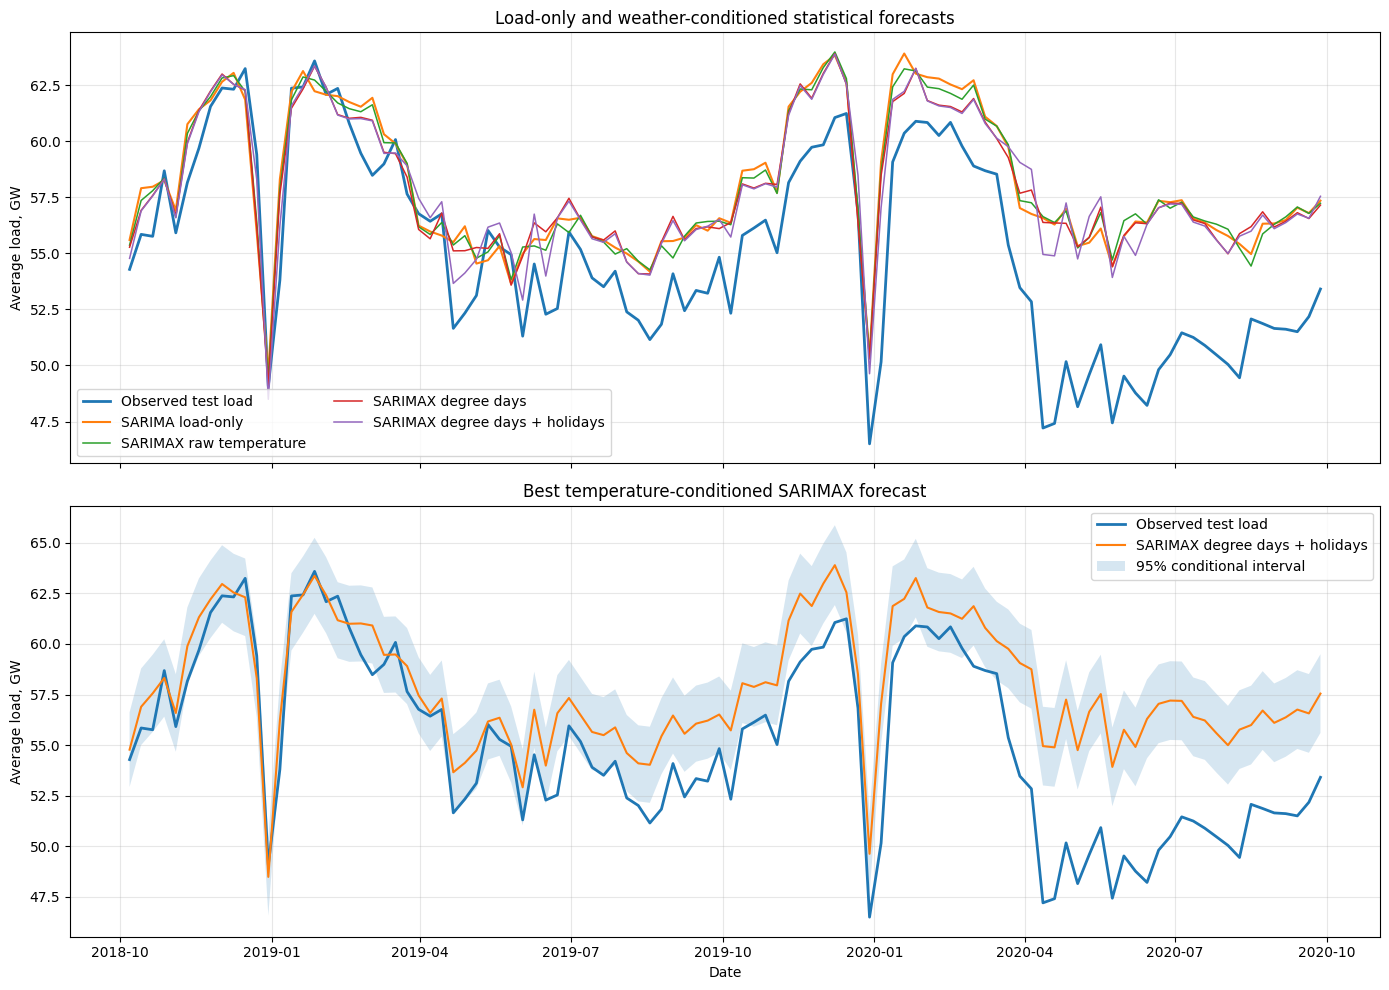

In [8]:
# =============================================================================
# CELL 7: SARIMAX MODELS WITH TEMPERATURE AND HOLIDAY VARIABLES
# =============================================================================
# This cell evaluates whether weather information improves the load-only
# SARIMA forecast.
#
# Three SARIMAX variants are compared:
# 1. Raw mean temperature
# 2. Heating and cooling degree days
# 3. Degree days together with public-holiday variables
#
# Actual temperature from the test period is supplied to these models.
# Therefore, the results are conditional forecasts rather than fully
# operational two-year-ahead forecasts.
# =============================================================================


# -----------------------------------------------------------------------------
# DEFINE CONTROLLED EXOGENOUS-VARIABLE SETS
# -----------------------------------------------------------------------------
# Testing separate feature sets allows the incremental forecasting value of
# raw temperature, engineered degree days and holidays to be evaluated.
# -----------------------------------------------------------------------------

sarimax_feature_sets = {
    "SARIMAX raw temperature": [
        "temp_mean"
    ],

    "SARIMAX degree days": [
        "heating_degree",
        "cooling_degree"
    ],

    "SARIMAX degree days + holidays": [
        "heating_degree",
        "cooling_degree",
        "holiday_days",
        "christmas_new_year"
    ]
}


sarimax_outputs = {}
sarimax_comparison_rows = []


# -----------------------------------------------------------------------------
# FIT AND EVALUATE EACH SARIMAX VARIANT
# -----------------------------------------------------------------------------

for model_name, feature_columns in sarimax_feature_sets.items():

    # Create separate training and test exogenous-variable matrices.
    X_train_exogenous = train_data[
        feature_columns
    ].astype(float)

    X_test_exogenous = test_data[
        feature_columns
    ].astype(float)


    # Standardisation is fitted only on the training period.
    # This prevents information from the test distribution entering training.
    exogenous_scaler = StandardScaler()

    X_train_scaled = pd.DataFrame(
        exogenous_scaler.fit_transform(
            X_train_exogenous
        ),
        index=X_train_exogenous.index,
        columns=feature_columns
    )

    X_test_scaled = pd.DataFrame(
        exogenous_scaler.transform(
            X_test_exogenous
        ),
        index=X_test_exogenous.index,
        columns=feature_columns
    )


    # A constant is used only when neither ordinary nor seasonal differencing
    # is present.
    if (
        best_nonseasonal_order[1] == 0
        and best_seasonal_order[1] == 0
    ):
        trend_setting = "c"
    else:
        trend_setting = "n"


    # Use the SARIMA orders selected in Cell 6.
    # This makes the comparison focus on the addition of weather information.
    sarimax_model = SARIMAX(
        y_train,
        exog=X_train_scaled,
        order=best_nonseasonal_order,
        seasonal_order=best_seasonal_order,
        trend=trend_setting,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    sarimax_fit = sarimax_model.fit(
        disp=False,
        maxiter=120
    )


    # The observed test-period temperature path is supplied as exogenous data.
    sarimax_forecast_object = (
        sarimax_fit.get_forecast(
            steps=len(y_test),
            exog=X_test_scaled
        )
    )

    sarimax_prediction = (
        sarimax_forecast_object
        .predicted_mean
    )

    sarimax_prediction.index = (
        y_test.index
    )


    # Generate the conditional 95% forecast interval.
    sarimax_interval_95 = (
        sarimax_forecast_object
        .conf_int(alpha=0.05)
    )

    sarimax_interval_95.index = (
        y_test.index
    )


    # Evaluate the conditional forecast.
    sarimax_metrics = evaluate_forecast(
        model_name=model_name,
        y_true=y_test,
        y_pred=sarimax_prediction,
        y_train=y_train,
        forecast_type="Conditional"
    )


    sarimax_metrics[
        "95% interval coverage"
    ] = float(
        (
            (
                y_test
                >= sarimax_interval_95.iloc[
                    :, 0
                ]
            )
            &
            (
                y_test
                <= sarimax_interval_95.iloc[
                    :, 1
                ]
            )
        ).mean()
    )


    sarimax_metrics[
        "Average 95% interval width"
    ] = float(
        (
            sarimax_interval_95.iloc[:, 1]
            - sarimax_interval_95.iloc[:, 0]
        ).mean()
    )


    # Store results for the final model comparison.
    results.append(
        sarimax_metrics
    )

    forecast_store[
        model_name
    ] = sarimax_prediction


    # Store the fitted model and supporting objects for later figures.
    sarimax_outputs[
        model_name
    ] = {
        "fit": sarimax_fit,
        "prediction": sarimax_prediction,
        "interval_95": sarimax_interval_95,
        "features": feature_columns,
        "scaler": exogenous_scaler
    }


    sarimax_comparison_rows.append(
        {
            "Model": model_name,
            "Features": ", ".join(
                feature_columns
            ),
            "AIC": sarimax_fit.aic,
            "BIC": sarimax_fit.bic,
            "MAE": sarimax_metrics["MAE"],
            "RMSE": sarimax_metrics["RMSE"],
            "MASE": sarimax_metrics["MASE"],
            "sMAPE": sarimax_metrics["sMAPE"],

            "95% interval coverage": (
                sarimax_metrics[
                    "95% interval coverage"
                ]
            ),

            "Average 95% interval width": (
                sarimax_metrics[
                    "Average 95% interval width"
                ]
            )
        }
    )


# -----------------------------------------------------------------------------
# CREATE THE SARIMAX COMPARISON TABLE
# -----------------------------------------------------------------------------

sarimax_comparison = (
    pd.DataFrame(
        sarimax_comparison_rows
    )
    .sort_values("RMSE")
    .reset_index(drop=True)
)

sarimax_comparison.to_csv(
    TABLE_DIR
    / "sarima_sarimax_comparison.csv",
    index=False
)

print(
    "SARIMAX model comparison:"
)

display(
    sarimax_comparison.round(3)
)


# Identify the best weather-conditioned statistical model by RMSE.
best_sarimax_name = (
    sarimax_comparison
    .iloc[0]["Model"]
)

best_sarimax_output = (
    sarimax_outputs[
        best_sarimax_name
    ]
)


# -----------------------------------------------------------------------------
# COMPARE LOAD-ONLY AND WEATHER-CONDITIONED FORECASTS
# -----------------------------------------------------------------------------

figure, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 10),
    sharex=True
)


# Upper panel: compare SARIMA and all SARIMAX variants.
axes[0].plot(
    y_test.index,
    y_test,
    label="Observed test load",
    linewidth=2
)

axes[0].plot(
    y_test.index,
    sarima_forecast,
    label="SARIMA load-only"
)

for model_name in sarimax_feature_sets:

    axes[0].plot(
        y_test.index,
        forecast_store[
            model_name
        ],
        label=model_name,
        linewidth=1.1
    )

axes[0].set_title(
    "Load-only and weather-conditioned statistical forecasts"
)

axes[0].set_ylabel(
    "Average load, GW"
)

axes[0].legend(
    ncol=2
)

axes[0].grid(
    alpha=0.3
)


# Lower panel: show the best SARIMAX model with its interval.
axes[1].plot(
    y_test.index,
    y_test,
    label="Observed test load",
    linewidth=2
)

axes[1].plot(
    y_test.index,
    best_sarimax_output[
        "prediction"
    ],
    label=best_sarimax_name
)

axes[1].fill_between(
    y_test.index,
    best_sarimax_output[
        "interval_95"
    ].iloc[:, 0],
    best_sarimax_output[
        "interval_95"
    ].iloc[:, 1],
    alpha=0.18,
    label="95% conditional interval"
)

axes[1].set_title(
    "Best temperature-conditioned SARIMAX forecast"
)

axes[1].set_xlabel(
    "Date"
)

axes[1].set_ylabel(
    "Average load, GW"
)

axes[1].legend()

axes[1].grid(
    alpha=0.3
)

plt.tight_layout()

save_current_figure(
    "08_sarima_sarimax_comparison.png"
)

Best Gradient Boosting parameters for each model variant:


,Candidate,Validation RMSE,n_estimators,learning_rate,max_depth,min_samples_leaf,subsample
Variant,,,,,,,
GB engineered weather,1,1.8484,150,0.03,2,5,0.90
GB load-only,2,1.9779,250,0.03,2,4,0.85
GB raw temperature,2,1.9831,250,0.03,2,4,0.85


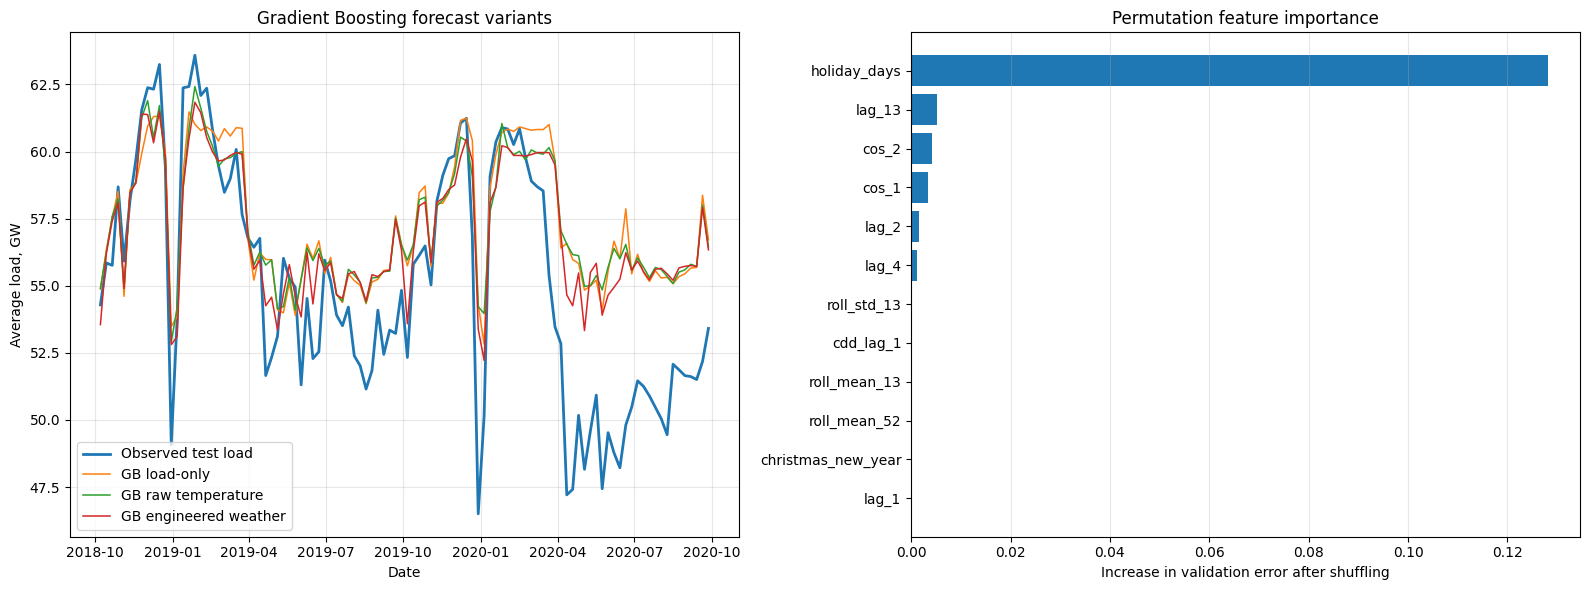

In [10]:
# =============================================================================
# CELL 8: GRADIENT BOOSTING WITH LOAD AND WEATHER FEATURES
# =============================================================================
# This cell compares three feature-based forecasting variants:
# 1. Load-history features only
# 2. Load-history features plus raw temperature
# 3. Load-history features plus engineered weather and holiday features
#
# A recursive forecast is used. After the forecast origin, previous model
# predictions are used as lagged load inputs. Actual test-period load values
# are never used to generate later test forecasts.
# =============================================================================


# -----------------------------------------------------------------------------
# DEFINE THE THREE FEATURE SETS
# -----------------------------------------------------------------------------

GRADIENT_BOOSTING_VARIANTS = {
    "GB load-only": [],

    "GB raw temperature": [
        "temp_mean",
        "temp_lag_1",
        "temp_lag_2"
    ],

    "GB engineered weather": [
        "temp_mean",
        "heating_degree",
        "cooling_degree",
        "temp_lag_1",
        "temp_lag_2",
        "hdd_lag_1",
        "cdd_lag_1",
        "temp_roll_4",
        "holiday_days",
        "christmas_new_year"
    ]
}


# Compact parameter set used to control execution time.
# The alternatives test different tree depths, learning rates and ensemble
# sizes without creating an excessively large search.
GRADIENT_BOOSTING_PARAMETERS = [
    {
        "n_estimators": 150,
        "learning_rate": 0.03,
        "max_depth": 2,
        "min_samples_leaf": 5,
        "subsample": 0.90
    },

    {
        "n_estimators": 250,
        "learning_rate": 0.03,
        "max_depth": 2,
        "min_samples_leaf": 4,
        "subsample": 0.85
    },

    {
        "n_estimators": 180,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_samples_leaf": 5,
        "subsample": 0.90
    },

    {
        "n_estimators": 200,
        "learning_rate": 0.04,
        "max_depth": 3,
        "min_samples_leaf": 5,
        "subsample": 0.85
    }
]


# Load lags capture short, medium and annual electricity-demand persistence.
LOAD_LAGS = [
    1,
    2,
    4,
    8,
    13,
    26,
    52
]


# -----------------------------------------------------------------------------
# CREATE THE TRAINING FEATURE TABLE
# -----------------------------------------------------------------------------

def create_gradient_boosting_table(
    load_series,
    full_data,
    weather_columns
):
    """
    Build lagged load, rolling, calendar and weather predictors.

    All rolling load variables are shifted by one week before calculation.
    Therefore, the current target is not included in its own predictor.
    """
    feature_table = pd.DataFrame(
        index=load_series.index
    )

    feature_table["target"] = (
        load_series
    )


    # Historical load lags.
    for lag in LOAD_LAGS:

        feature_table[
            f"lag_{lag}"
        ] = load_series.shift(lag)


    # Shift before rolling to avoid target leakage.
    feature_table["roll_mean_4"] = (
        load_series
        .shift(1)
        .rolling(4)
        .mean()
    )

    feature_table["roll_mean_13"] = (
        load_series
        .shift(1)
        .rolling(13)
        .mean()
    )

    feature_table["roll_mean_52"] = (
        load_series
        .shift(1)
        .rolling(52)
        .mean()
    )

    feature_table["roll_std_13"] = (
        load_series
        .shift(1)
        .rolling(13)
        .std()
    )


    # Fourier terms represent annual seasonality smoothly.
    week_number = (
        feature_table.index
        .isocalendar()
        .week
        .astype(int)
    )

    feature_table["sin_1"] = np.sin(
        2 * np.pi
        * week_number / 52
    )

    feature_table["cos_1"] = np.cos(
        2 * np.pi
        * week_number / 52
    )

    feature_table["sin_2"] = np.sin(
        4 * np.pi
        * week_number / 52
    )

    feature_table["cos_2"] = np.cos(
        4 * np.pi
        * week_number / 52
    )


    # Time index allows the model to capture gradual long-term change.
    feature_table["time_index"] = np.arange(
        len(feature_table)
    )


    # Add the selected weather and holiday predictors.
    for column in weather_columns:

        feature_table[column] = (
            full_data.loc[
                feature_table.index,
                column
            ]
        )


    # Early observations without sufficient lag history are removed.
    return feature_table.dropna()


# -----------------------------------------------------------------------------
# CREATE ONE FUTURE FEATURE ROW DURING RECURSIVE FORECASTING
# -----------------------------------------------------------------------------

def create_recursive_feature_row(
    forecast_date,
    available_load_history,
    full_data,
    weather_columns,
    time_origin
):
    """
    Construct predictors for one future week.

    During the test period, load lags are calculated from:
    - Actual training observations before the forecast origin.
    - Previous model predictions after the forecast origin.

    Actual future load values are never used.
    """
    available_load_history = (
        pd.Series(
            available_load_history
        )
        .sort_index()
    )

    feature_row = {}


    # Add load lags.
    for lag in LOAD_LAGS:

        feature_row[
            f"lag_{lag}"
        ] = (
            available_load_history
            .iloc[-lag]
        )


    # Add rolling load statistics using only available history.
    feature_row["roll_mean_4"] = (
        available_load_history
        .iloc[-4:]
        .mean()
    )

    feature_row["roll_mean_13"] = (
        available_load_history
        .iloc[-13:]
        .mean()
    )

    feature_row["roll_mean_52"] = (
        available_load_history
        .iloc[-52:]
        .mean()
    )

    feature_row["roll_std_13"] = (
        available_load_history
        .iloc[-13:]
        .std()
    )


    # Add annual Fourier terms.
    week_number = int(
        forecast_date
        .isocalendar()
        .week
    )

    feature_row["sin_1"] = np.sin(
        2 * np.pi
        * week_number / 52
    )

    feature_row["cos_1"] = np.cos(
        2 * np.pi
        * week_number / 52
    )

    feature_row["sin_2"] = np.sin(
        4 * np.pi
        * week_number / 52
    )

    feature_row["cos_2"] = np.cos(
        4 * np.pi
        * week_number / 52
    )


    feature_row["time_index"] = int(
        (
            forecast_date
            - time_origin
        ).days / 7
    )


    # Add weather and holiday variables for the forecast week.
    # Current observed temperature produces a conditional forecast.
    for column in weather_columns:

        feature_row[column] = (
            full_data.loc[
                forecast_date,
                column
            ]
        )


    return pd.DataFrame(
        [feature_row],
        index=[forecast_date]
    )


# -----------------------------------------------------------------------------
# RECURSIVE MULTI-STEP FORECAST FUNCTION
# -----------------------------------------------------------------------------

def recursive_gradient_boosting_forecast(
    model,
    initial_history,
    forecast_index,
    full_data,
    weather_columns,
    feature_columns
):
    """
    Forecast every future week recursively.

    Each prediction is added to the available load history before the next
    forecast is generated. This avoids using actual test load as a lag.
    """
    available_history = (
        initial_history.copy()
    )

    predictions = []
    generated_feature_rows = []

    time_origin = (
        available_history.index[0]
    )

    for forecast_date in forecast_index:

        future_row = (
            create_recursive_feature_row(
                forecast_date=forecast_date,
                available_load_history=(
                    available_history
                ),
                full_data=full_data,
                weather_columns=(
                    weather_columns
                ),
                time_origin=time_origin
            )
        )

        future_row = future_row.reindex(
            columns=feature_columns
        )

        forecast_value = float(
            model.predict(
                future_row
            )[0]
        )

        predictions.append(
            forecast_value
        )

        generated_feature_rows.append(
            future_row
        )

        # Add the prediction, not the actual test observation, to history.
        available_history.loc[
            forecast_date
        ] = forecast_value


    prediction_series = pd.Series(
        predictions,
        index=forecast_index
    )

    generated_features = pd.concat(
        generated_feature_rows
    )

    return (
        prediction_series,
        generated_features
    )


# -----------------------------------------------------------------------------
# CREATE AN INTERNAL VALIDATION PERIOD
# -----------------------------------------------------------------------------
# The final 26 weeks of training data are used for parameter selection.
# The official 104-week test set remains untouched until final evaluation.
# -----------------------------------------------------------------------------

validation_weeks = 26

subtraining_load = y_train.iloc[
    :-validation_weeks
]

validation_load = y_train.iloc[
    -validation_weeks:
]


gradient_boosting_tuning_rows = []
gradient_boosting_outputs = {}

engineered_weather_validation_package = None


# -----------------------------------------------------------------------------
# TUNE AND FIT EACH GRADIENT BOOSTING VARIANT
# -----------------------------------------------------------------------------

for (
    variant_name,
    weather_columns
) in GRADIENT_BOOSTING_VARIANTS.items():


    # Build the feature table using only the subtraining load period.
    subtraining_table = (
        create_gradient_boosting_table(
            load_series=subtraining_load,
            full_data=weekly_data,
            weather_columns=weather_columns
        )
    )

    X_subtraining = (
        subtraining_table
        .drop(columns="target")
    )

    y_subtraining_target = (
        subtraining_table["target"]
    )

    parameter_evaluations = []


    # Compare each compact parameter candidate.
    for (
        candidate_number,
        candidate_parameters
    ) in enumerate(
        GRADIENT_BOOSTING_PARAMETERS,
        start=1
    ):

        candidate_model = (
            GradientBoostingRegressor(
                random_state=RANDOM_STATE,
                **candidate_parameters
            )
        )

        candidate_model.fit(
            X_subtraining,
            y_subtraining_target
        )


        # Forecast the validation period recursively.
        (
            validation_prediction,
            validation_feature_rows
        ) = recursive_gradient_boosting_forecast(
            model=candidate_model,
            initial_history=subtraining_load,
            forecast_index=(
                validation_load.index
            ),
            full_data=weekly_data,
            weather_columns=weather_columns,
            feature_columns=(
                X_subtraining.columns
            )
        )


        validation_rmse = (
            calculate_rmse(
                validation_load,
                validation_prediction
            )
        )


        gradient_boosting_tuning_rows.append(
            {
                "Variant": variant_name,
                "Candidate": candidate_number,
                "Validation RMSE": (
                    validation_rmse
                ),
                **candidate_parameters
            }
        )


        parameter_evaluations.append(
            (
                validation_rmse,
                candidate_parameters,
                candidate_model,
                validation_prediction,
                validation_feature_rows
            )
        )


    # Select the parameter set with the lowest recursive validation RMSE.
    parameter_evaluations.sort(
        key=lambda item: item[0]
    )

    (
        best_validation_rmse,
        best_parameters,
        best_validation_model,
        best_validation_prediction,
        best_validation_features
    ) = parameter_evaluations[0]


    # Recreate features using the complete training period.
    complete_training_table = (
        create_gradient_boosting_table(
            load_series=y_train,
            full_data=weekly_data,
            weather_columns=weather_columns
        )
    )

    X_complete_training = (
        complete_training_table
        .drop(columns="target")
    )

    y_complete_training = (
        complete_training_table[
            "target"
        ]
    )


    # Fit the selected model using all available training observations.
    final_gradient_boosting_model = (
        GradientBoostingRegressor(
            random_state=RANDOM_STATE,
            **best_parameters
        )
    )

    final_gradient_boosting_model.fit(
        X_complete_training,
        y_complete_training
    )


    # Generate the final recursive two-year forecast.
    (
        test_prediction,
        test_feature_rows
    ) = recursive_gradient_boosting_forecast(
        model=final_gradient_boosting_model,
        initial_history=y_train,
        forecast_index=y_test.index,
        full_data=weekly_data,
        weather_columns=weather_columns,
        feature_columns=(
            X_complete_training.columns
        )
    )


    # Load-only is operational.
    # Weather variants are conditional because observed future weather is used.
    if variant_name == "GB load-only":
        forecast_type = "Operational"
    else:
        forecast_type = "Conditional"


    gradient_boosting_metrics = (
        evaluate_forecast(
            model_name=variant_name,
            y_true=y_test,
            y_pred=test_prediction,
            y_train=y_train,
            forecast_type=forecast_type
        )
    )


    results.append(
        gradient_boosting_metrics
    )

    forecast_store[
        variant_name
    ] = test_prediction


    gradient_boosting_outputs[
        variant_name
    ] = {
        "model": (
            final_gradient_boosting_model
        ),
        "parameters": best_parameters,
        "validation_rmse": (
            best_validation_rmse
        ),
        "prediction": test_prediction,
        "features": (
            X_complete_training
            .columns
            .tolist()
        )
    }


    # Keep the validation objects for permutation importance.
    if (
        variant_name
        == "GB engineered weather"
    ):
        engineered_weather_validation_package = {
            "model": best_validation_model,
            "X": best_validation_features,
            "y": validation_load
        }


# -----------------------------------------------------------------------------
# DISPLAY AND SAVE TUNING RESULTS
# -----------------------------------------------------------------------------

gradient_boosting_tuning_results = (
    pd.DataFrame(
        gradient_boosting_tuning_rows
    )
    .sort_values(
        [
            "Variant",
            "Validation RMSE"
        ]
    )
)

gradient_boosting_tuning_results.to_csv(
    TABLE_DIR
    / "gradient_boosting_tuning.csv",
    index=False
)


print(
    "Best Gradient Boosting parameters "
    "for each model variant:"
)

display(
    gradient_boosting_tuning_results
    .groupby("Variant")
    .first()
    .round(4)
)


# -----------------------------------------------------------------------------
# PERMUTATION FEATURE IMPORTANCE
# -----------------------------------------------------------------------------
# Permutation importance measures how much validation accuracy decreases when
# one feature is randomly shuffled. This is more reliable than interpreting
# only impurity-based tree importance.
# -----------------------------------------------------------------------------

permutation_result = permutation_importance(
    engineered_weather_validation_package[
        "model"
    ],
    engineered_weather_validation_package[
        "X"
    ],
    engineered_weather_validation_package[
        "y"
    ],
    scoring="neg_root_mean_squared_error",
    n_repeats=20,
    random_state=RANDOM_STATE
)


feature_importance_table = pd.DataFrame(
    {
        "Feature": (
            engineered_weather_validation_package[
                "X"
            ].columns
        ),

        "Importance": (
            permutation_result
            .importances_mean
        ),

        "Standard deviation": (
            permutation_result
            .importances_std
        )
    }
).sort_values(
    "Importance",
    ascending=False
)


feature_importance_table.to_csv(
    TABLE_DIR
    / "gradient_boosting_feature_importance.csv",
    index=False
)


# -----------------------------------------------------------------------------
# COMBINED FORECAST AND FEATURE-IMPORTANCE FIGURE
# -----------------------------------------------------------------------------

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)


# Left panel: compare the three Gradient Boosting forecasts.
axes[0].plot(
    y_test.index,
    y_test,
    label="Observed test load",
    linewidth=2
)

for variant_name in GRADIENT_BOOSTING_VARIANTS:

    axes[0].plot(
        y_test.index,
        forecast_store[
            variant_name
        ],
        label=variant_name,
        linewidth=1.1
    )

axes[0].set_title(
    "Gradient Boosting forecast variants"
)

axes[0].set_xlabel(
    "Date"
)

axes[0].set_ylabel(
    "Average load, GW"
)

axes[0].legend()

axes[0].grid(
    alpha=0.3
)


# Right panel: show the 12 most important features.
top_features = (
    feature_importance_table
    .head(12)
    .sort_values("Importance")
)

axes[1].barh(
    top_features["Feature"],
    top_features["Importance"]
)

axes[1].set_title(
    "Permutation feature importance"
)

axes[1].set_xlabel(
    "Increase in validation error after shuffling"
)

axes[1].grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

save_current_figure(
    "09_gradient_boosting_results.png"
)

LSTM architecture comparison:


,Architecture,First layer units,Second layer units,Dropout,Learning rate,Validation RMSE,Epochs completed
0,One LSTM layer,32,NaN,0.10,0.001,5.1594,8
1,Two LSTM layers,48,24.0,0.15,0.001,5.2218,8


Hourly LSTM evaluation:


,Model,MAE,RMSE,sMAPE
0,Hourly seasonal naive,4.4207,5.6832,8.0927
1,Hourly LSTM,6.3751,7.6429,11.6180


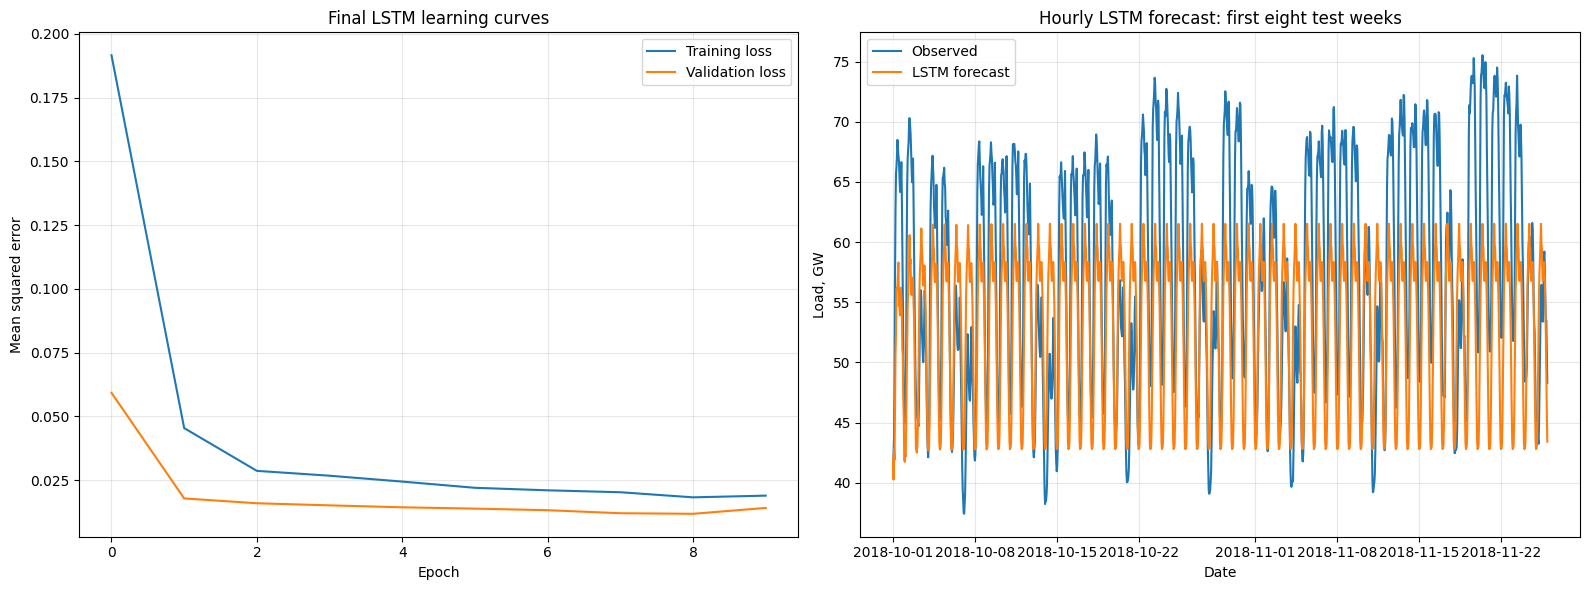

In [11]:
# =============================================================================
# CELL 9: HOURLY LSTM MODEL AND TWO-YEAR FORECAST
# =============================================================================
# This cell builds a neural-network model using hourly electricity demand.
#
# The model:
# 1. Uses the previous 168 hours to predict the next 24 hours.
# 2. Compares two compact LSTM architectures.
# 3. Uses an internal validation period for architecture selection.
# 4. Produces a recursive forecast for the final two years.
# 5. Aggregates hourly forecasts to weekly averages for model comparison.
#
# TensorFlow is required. Google Colab is recommended for this cell.
# =============================================================================


# -----------------------------------------------------------------------------
# IMPORT TENSORFLOW
# -----------------------------------------------------------------------------

import tensorflow as tf

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)


# Fix seeds for reproducible neural-network initialisation.
np.random.seed(
    RANDOM_STATE
)

tf.random.set_seed(
    RANDOM_STATE
)


# -----------------------------------------------------------------------------
# ALIGN HOURLY TRAINING AND TEST PERIODS WITH THE WEEKLY SPLIT
# -----------------------------------------------------------------------------
# The first weekly test label represents the Sunday at the end of that week.
# Six days are subtracted so that the corresponding hourly test period begins
# at the start of the same week.
# -----------------------------------------------------------------------------

hourly_test_start = (
    y_test.index[0]
    - pd.Timedelta(days=6)
)

hourly_test_end = (
    y_test.index[-1]
    + pd.Timedelta(hours=23)
)


hourly_training_load = (
    hourly_load_gw.loc[
        hourly_load_gw.index
        < hourly_test_start
    ]
    .dropna()
)

hourly_test_load = (
    hourly_load_gw.loc[
        hourly_test_start:
        hourly_test_end
    ]
    .dropna()
)


# The previous seven days are used as model input.
LSTM_LOOKBACK = 168

# The model predicts one complete day at a time.
LSTM_FORECAST_HORIZON = 24

# The final 13 weeks of hourly training data are used for validation.
LSTM_VALIDATION_HOURS = (
    13 * 168
)


# -----------------------------------------------------------------------------
# CREATE SUPERVISED LSTM SEQUENCES
# -----------------------------------------------------------------------------

def create_lstm_sequences(
    scaled_values,
    lookback=168,
    horizon=24,
    stride=24
):
    """
    Convert an hourly series into input-output sequence pairs.

    Input:
    Previous 168 hourly load observations.

    Output:
    Next 24 hourly load observations.

    A stride of 24 creates one training sequence per day.
    """
    input_sequences = []
    output_sequences = []

    for end_position in range(
        lookback,
        len(scaled_values) - horizon + 1,
        stride
    ):

        input_sequences.append(
            scaled_values[
                end_position - lookback:
                end_position
            ]
        )

        output_sequences.append(
            scaled_values[
                end_position:
                end_position + horizon
            ].reshape(-1)
        )

    return (
        np.asarray(
            input_sequences
        ),
        np.asarray(
            output_sequences
        )
    )


# -----------------------------------------------------------------------------
# BUILD ONE LSTM ARCHITECTURE
# -----------------------------------------------------------------------------

def build_lstm_model(
    first_layer_units,
    second_layer_units,
    dropout_rate,
    learning_rate
):
    """
    Create either a one-layer or two-layer LSTM model.
    """
    model = Sequential()

    model.add(
        Input(
            shape=(
                LSTM_LOOKBACK,
                1
            )
        )
    )


    # Use one LSTM layer when second_layer_units is None.
    if second_layer_units is None:

        model.add(
            LSTM(
                first_layer_units
            )
        )


    # Otherwise, create a stacked two-layer architecture.
    else:

        model.add(
            LSTM(
                first_layer_units,
                return_sequences=True
            )
        )

        model.add(
            Dropout(
                dropout_rate
            )
        )

        model.add(
            LSTM(
                second_layer_units
            )
        )


    model.add(
        Dropout(
            dropout_rate
        )
    )


    # Dense output contains the next 24 hourly predictions.
    model.add(
        Dense(
            LSTM_FORECAST_HORIZON
        )
    )


    model.compile(
        optimizer=(
            tf.keras.optimizers.Adam(
                learning_rate=learning_rate
            )
        ),
        loss="mse"
    )

    return model


# -----------------------------------------------------------------------------
# DEFINE COMPACT ARCHITECTURE CANDIDATES
# -----------------------------------------------------------------------------

lstm_architecture_candidates = [
    {
        "Architecture": "One LSTM layer",
        "first_layer_units": 32,
        "second_layer_units": None,
        "dropout_rate": 0.10,
        "learning_rate": 0.001
    },

    {
        "Architecture": "Two LSTM layers",
        "first_layer_units": 48,
        "second_layer_units": 24,
        "dropout_rate": 0.15,
        "learning_rate": 0.001
    }
]


# -----------------------------------------------------------------------------
# CREATE INTERNAL TRAINING AND VALIDATION PERIODS
# -----------------------------------------------------------------------------

lstm_subtraining_load = (
    hourly_training_load.iloc[
        :-LSTM_VALIDATION_HOURS
    ]
)

lstm_validation_load = (
    hourly_training_load.iloc[
        -LSTM_VALIDATION_HOURS:
    ]
)


# Fit the scaler only on the subtraining period.
validation_scaler = MinMaxScaler()

subtraining_scaled = (
    validation_scaler.fit_transform(
        lstm_subtraining_load
        .to_numpy()
        .reshape(-1, 1)
    )
)


# Include the final lookback window from subtraining before validation.
validation_context = pd.concat(
    [
        lstm_subtraining_load.iloc[
            -LSTM_LOOKBACK:
        ],
        lstm_validation_load
    ]
)

validation_context_scaled = (
    validation_scaler.transform(
        validation_context
        .to_numpy()
        .reshape(-1, 1)
    )
)


# Convert subtraining and validation series into LSTM sequences.
(
    X_lstm_subtraining,
    y_lstm_subtraining
) = create_lstm_sequences(
    subtraining_scaled,
    lookback=LSTM_LOOKBACK,
    horizon=LSTM_FORECAST_HORIZON,
    stride=24
)

(
    X_lstm_validation,
    y_lstm_validation
) = create_lstm_sequences(
    validation_context_scaled,
    lookback=LSTM_LOOKBACK,
    horizon=LSTM_FORECAST_HORIZON,
    stride=24
)


# -----------------------------------------------------------------------------
# COMPARE THE TWO ARCHITECTURES
# -----------------------------------------------------------------------------

lstm_search_rows = {}

best_lstm_configuration = None
best_lstm_validation_rmse = np.inf


for configuration in lstm_architecture_candidates:

    tf.keras.backend.clear_session()

    candidate_lstm_model = build_lstm_model(
        first_layer_units=(
            configuration[
                "first_layer_units"
            ]
        ),

        second_layer_units=(
            configuration[
                "second_layer_units"
            ]
        ),

        dropout_rate=(
            configuration[
                "dropout_rate"
            ]
        ),

        learning_rate=(
            configuration[
                "learning_rate"
            ]
        )
    )


    # Stop training when validation loss no longer improves.
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )


    candidate_history = (
        candidate_lstm_model.fit(
            X_lstm_subtraining,
            y_lstm_subtraining,

            validation_data=(
                X_lstm_validation,
                y_lstm_validation
            ),

            epochs=8,
            batch_size=32,

            # Time-series observations must remain in chronological order.
            shuffle=False,

            verbose=0,
            callbacks=[
                early_stopping
            ]
        )
    )


    # Predict the validation sequences.
    validation_prediction_scaled = (
        candidate_lstm_model.predict(
            X_lstm_validation,
            verbose=0
        )
    )


    # Convert scaled predictions back to gigawatts.
    validation_prediction = (
        validation_scaler
        .inverse_transform(
            validation_prediction_scaled
            .reshape(-1, 1)
        )
        .reshape(
            validation_prediction_scaled.shape
        )
    )


    validation_actual = (
        validation_scaler
        .inverse_transform(
            y_lstm_validation
            .reshape(-1, 1)
        )
        .reshape(
            y_lstm_validation.shape
        )
    )


    architecture_rmse = (
        calculate_rmse(
            validation_actual.ravel(),
            validation_prediction.ravel()
        )
    )


    lstm_search_rows[
        configuration[
            "Architecture"
        ]
    ] = {
        "Architecture": (
            configuration[
                "Architecture"
            ]
        ),

        "First layer units": (
            configuration[
                "first_layer_units"
            ]
        ),

        "Second layer units": (
            configuration[
                "second_layer_units"
            ]
        ),

        "Dropout": (
            configuration[
                "dropout_rate"
            ]
        ),

        "Learning rate": (
            configuration[
                "learning_rate"
            ]
        ),

        "Validation RMSE": (
            architecture_rmse
        ),

        "Epochs completed": len(
            candidate_history.history[
                "loss"
            ]
        )
    }


    if (
        architecture_rmse
        < best_lstm_validation_rmse
    ):

        best_lstm_validation_rmse = (
            architecture_rmse
        )

        best_lstm_configuration = (
            configuration.copy()
        )


lstm_search_results = (
    pd.DataFrame(
        lstm_search_rows.values()
    )
    .sort_values(
        "Validation RMSE"
    )
)

lstm_search_results.to_csv(
    TABLE_DIR
    / "lstm_architecture_search.csv",
    index=False
)


print(
    "LSTM architecture comparison:"
)

display(
    lstm_search_results.round(4)
)


# -----------------------------------------------------------------------------
# REFIT THE BEST ARCHITECTURE USING THE COMPLETE HOURLY TRAINING PERIOD
# -----------------------------------------------------------------------------

final_hourly_scaler = MinMaxScaler()

complete_hourly_training_scaled = (
    final_hourly_scaler
    .fit_transform(
        hourly_training_load
        .to_numpy()
        .reshape(-1, 1)
    )
)


(
    X_lstm_complete,
    y_lstm_complete
) = create_lstm_sequences(
    complete_hourly_training_scaled,
    lookback=LSTM_LOOKBACK,
    horizon=LSTM_FORECAST_HORIZON,
    stride=24
)


tf.keras.backend.clear_session()


final_lstm_model = build_lstm_model(
    first_layer_units=(
        best_lstm_configuration[
            "first_layer_units"
        ]
    ),

    second_layer_units=(
        best_lstm_configuration[
            "second_layer_units"
        ]
    ),

    dropout_rate=(
        best_lstm_configuration[
            "dropout_rate"
        ]
    ),

    learning_rate=(
        best_lstm_configuration[
            "learning_rate"
        ]
    )
)


final_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


final_lstm_history = final_lstm_model.fit(
    X_lstm_complete,
    y_lstm_complete,

    validation_split=0.10,

    epochs=10,
    batch_size=32,

    shuffle=False,
    verbose=0,

    callbacks=[
        final_early_stopping
    ]
)


# -----------------------------------------------------------------------------
# RECURSIVE TWO-YEAR HOURLY FORECAST
# -----------------------------------------------------------------------------
# The first prediction uses the final 168 observed training hours.
# Later predictions use previous LSTM outputs. Actual test load is never fed
# back into the model.
# -----------------------------------------------------------------------------

scaled_history_window = (
    complete_hourly_training_scaled[
        -LSTM_LOOKBACK:
    ].copy()
)

required_forecast_hours = len(
    hourly_test_load
)

recursive_scaled_predictions = []


while (
    len(recursive_scaled_predictions)
    < required_forecast_hours
):

    next_24_hour_block = (
        final_lstm_model(
            scaled_history_window[
                np.newaxis,
                :,
                :
            ],
            training=False
        )
        .numpy()
        .reshape(-1)
    )


    remaining_hours = (
        required_forecast_hours
        - len(
            recursive_scaled_predictions
        )
    )


    accepted_prediction_block = (
        next_24_hour_block[
            :remaining_hours
        ]
    )


    recursive_scaled_predictions.extend(
        accepted_prediction_block.tolist()
    )


    # Update the sequence using the full predicted 24-hour block.
    block_for_history = (
        next_24_hour_block
        .reshape(-1, 1)
    )

    scaled_history_window = np.vstack(
        [
            scaled_history_window[
                len(block_for_history):
            ],
            block_for_history
        ]
    )


# Convert all recursive predictions back to gigawatts.
hourly_lstm_prediction = (
    final_hourly_scaler
    .inverse_transform(
        np.asarray(
            recursive_scaled_predictions
        ).reshape(-1, 1)
    )
    .reshape(-1)
)


hourly_lstm_forecast = pd.Series(
    hourly_lstm_prediction,
    index=hourly_test_load.index,
    name="Hourly LSTM forecast"
)


# -----------------------------------------------------------------------------
# HOURLY SEASONAL-NAIVE BENCHMARK
# -----------------------------------------------------------------------------
# The final 168 training hours are repeated across the test period.
# -----------------------------------------------------------------------------

final_training_week_hourly = (
    hourly_training_load
    .iloc[-168:]
    .to_numpy()
)

hourly_seasonal_naive = pd.Series(
    np.resize(
        final_training_week_hourly,
        len(hourly_test_load)
    ),
    index=hourly_test_load.index
)


# -----------------------------------------------------------------------------
# AGGREGATE THE HOURLY LSTM FORECAST TO WEEKLY AVERAGES
# -----------------------------------------------------------------------------

weekly_lstm_forecast = (
    hourly_lstm_forecast
    .resample("W-SUN")
    .mean()
    .reindex(
        y_test.index
    )
)


# Add the weekly LSTM results to the final comparison.
results.append(
    evaluate_forecast(
        model_name="LSTM aggregated weekly",
        y_true=y_test,
        y_pred=weekly_lstm_forecast,
        y_train=y_train,
        forecast_type="Operational"
    )
)

forecast_store[
    "LSTM aggregated weekly"
] = weekly_lstm_forecast


# -----------------------------------------------------------------------------
# EVALUATE HOURLY LSTM AND HOURLY SEASONAL-NAIVE FORECASTS
# -----------------------------------------------------------------------------

hourly_lstm_results = pd.DataFrame(
    [
        {
            "Model": "Hourly seasonal naive",

            "MAE": mean_absolute_error(
                hourly_test_load,
                hourly_seasonal_naive
            ),

            "RMSE": calculate_rmse(
                hourly_test_load,
                hourly_seasonal_naive
            ),

            "sMAPE": calculate_smape(
                hourly_test_load,
                hourly_seasonal_naive
            )
        },

        {
            "Model": "Hourly LSTM",

            "MAE": mean_absolute_error(
                hourly_test_load,
                hourly_lstm_forecast
            ),

            "RMSE": calculate_rmse(
                hourly_test_load,
                hourly_lstm_forecast
            ),

            "sMAPE": calculate_smape(
                hourly_test_load,
                hourly_lstm_forecast
            )
        }
    ]
)


hourly_lstm_results.to_csv(
    TABLE_DIR
    / "lstm_hourly_metrics.csv",
    index=False
)


print(
    "Hourly LSTM evaluation:"
)

display(
    hourly_lstm_results.round(4)
)


# -----------------------------------------------------------------------------
# COMBINED LSTM LEARNING-CURVE AND FORECAST FIGURE
# -----------------------------------------------------------------------------

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)


# Left panel: training and validation losses.
axes[0].plot(
    final_lstm_history.history[
        "loss"
    ],
    label="Training loss"
)

axes[0].plot(
    final_lstm_history.history[
        "val_loss"
    ],
    label="Validation loss"
)

axes[0].set_title(
    "Final LSTM learning curves"
)

axes[0].set_xlabel(
    "Epoch"
)

axes[0].set_ylabel(
    "Mean squared error"
)

axes[0].legend()

axes[0].grid(
    alpha=0.3
)


# Right panel: first eight test weeks for readable visual comparison.
hours_to_display = 8 * 168

axes[1].plot(
    hourly_test_load.index[
        :hours_to_display
    ],
    hourly_test_load.iloc[
        :hours_to_display
    ],
    label="Observed"
)

axes[1].plot(
    hourly_lstm_forecast.index[
        :hours_to_display
    ],
    hourly_lstm_forecast.iloc[
        :hours_to_display
    ],
    label="LSTM forecast"
)

axes[1].set_title(
    "Hourly LSTM forecast: first eight test weeks"
)

axes[1].set_xlabel(
    "Date"
)

axes[1].set_ylabel(
    "Load, GW"
)

axes[1].legend()

axes[1].grid(
    alpha=0.3
)

plt.tight_layout()

save_current_figure(
    "10_lstm_training_and_forecast.png"
)

Final forecasting-model comparison:


,Model,Forecast type,MAE,RMSE,MASE,sMAPE,Bias,95% interval coverage,Average 95% interval width,RMSE improvement over seasonal naive (%)
0,Seasonal naive,Operational,2.288,2.988,1.694,4.207,1.748,NaN,NaN,0.000
1,GB engineered weather,Conditional,2.455,3.178,1.817,4.532,1.803,NaN,NaN,-6.337
2,GB raw temperature,Conditional,2.632,3.482,1.948,4.862,2.071,NaN,NaN,-16.538
3,GB load-only,Operational,2.706,3.528,2.003,4.979,2.181,NaN,NaN,-18.066
4,SARIMAX degree days + holidays,Conditional,2.825,3.557,2.091,5.162,2.714,0.462,3.840,-19.025
5,SARIMAX degree days,Conditional,2.971,3.715,2.199,5.428,2.747,0.500,4.765,-24.307
6,SARIMAX raw temperature,Conditional,3.048,3.803,2.256,5.551,2.853,0.510,5.518,-27.254
7,SARIMA,Operational,3.140,3.837,2.324,5.706,2.908,0.500,5.513,-28.401
8,Mean,Operational,3.790,4.402,2.805,6.874,0.561,NaN,NaN,-47.312
9,Drift,Operational,3.851,4.466,2.850,6.982,0.966,NaN,NaN,-49.469


Temperature feature definitions:


,Feature,Definition,Purpose
0,Weekly mean temperature,Average of Berlin daily mean temperature withi...,Represents the general weekly temperature level
1,Lagged temperature,Berlin mean temperature observed one or two we...,Represents delayed weather effects without usi...
2,Heating degree days,"Weekly sum of max(15.5 - daily temperature, 0)",Measures the intensity of cold weather conditions
3,Cooling degree days,"Weekly sum of max(daily temperature - 22.0, 0)",Measures the intensity of hot weather conditions


Availability of forecasting covariates:


,Covariate,Known at forecast origin,Forecast interpretation
0,Calendar week and season,Yes,Operational
1,German public holidays,Yes,Operational
2,Historical electricity load,Yes,Operational up to the forecast origin
3,Observed future temperature,No,Conditional only
4,Weather forecast,Partly,Operational with weather-forecast uncertainty
5,Temperature climatology,Yes,Operational but less responsive to actual futu...


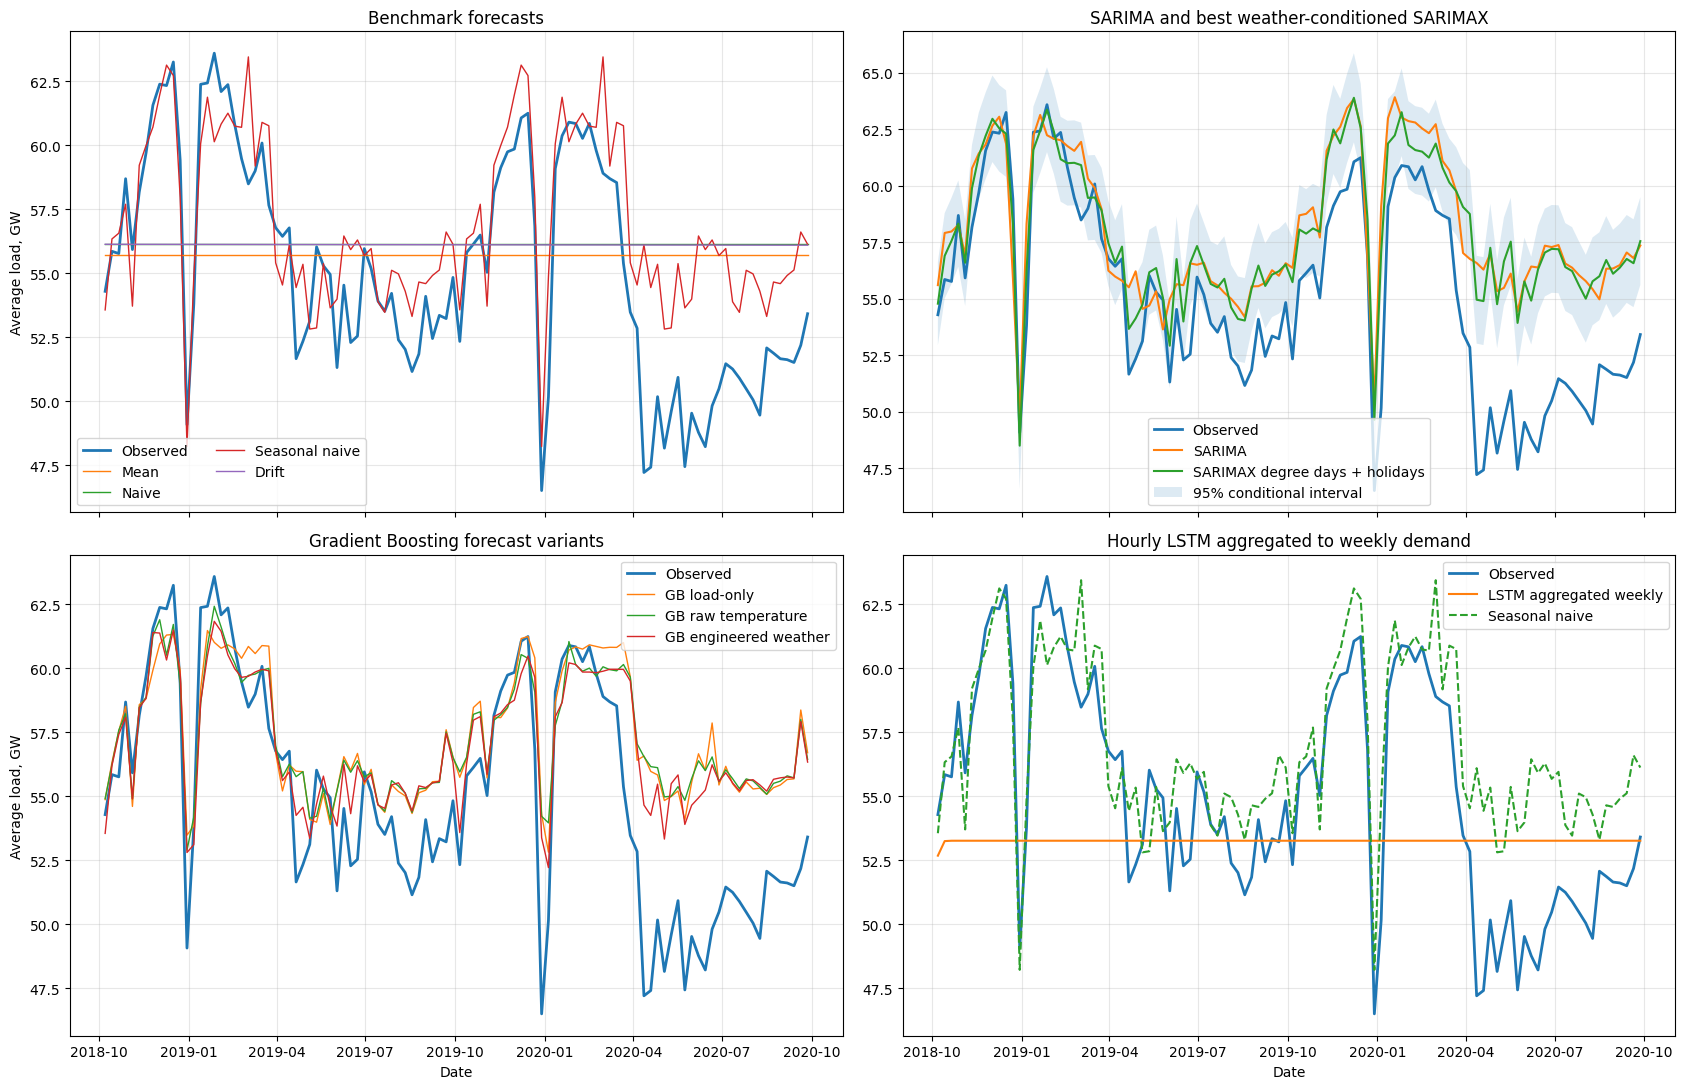

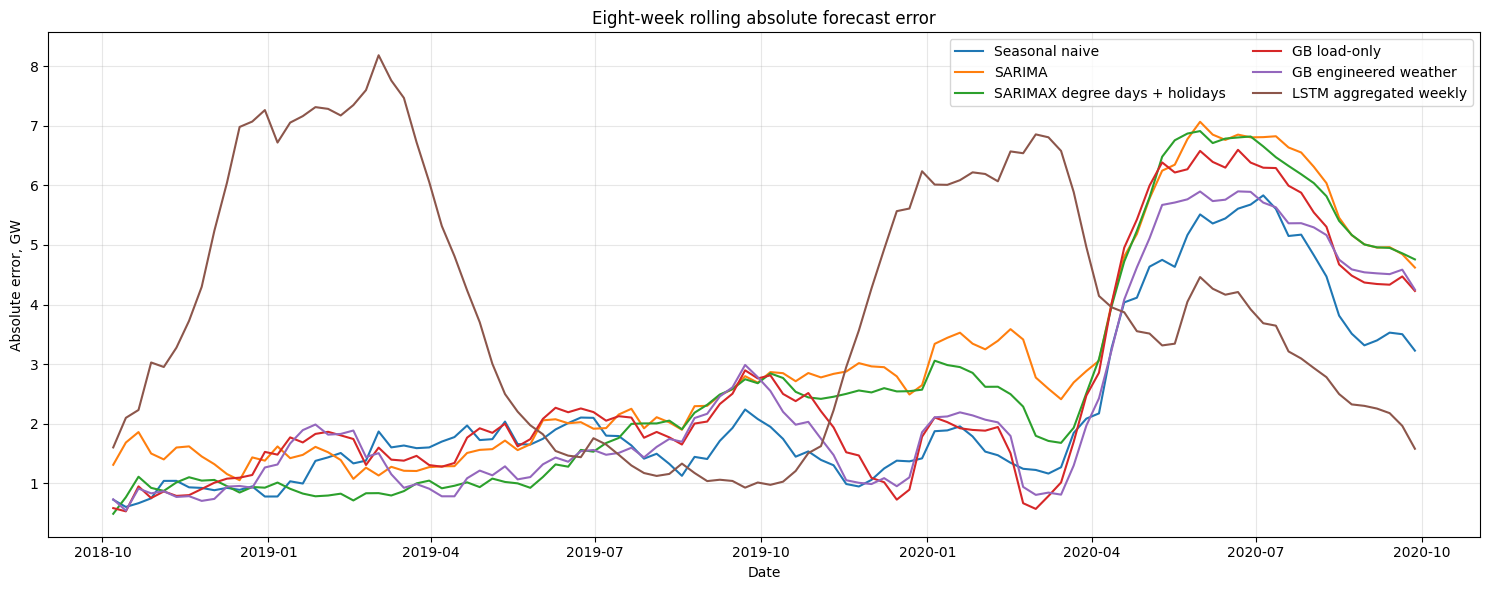

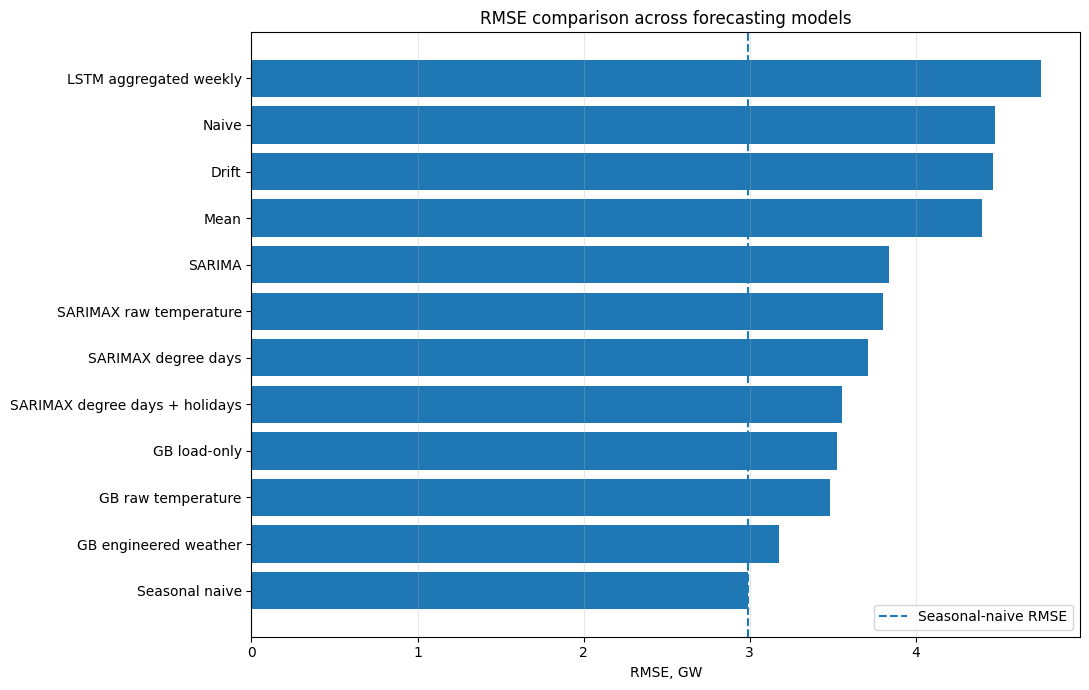

All figures were saved in: /content/outputs/figures
All tables were saved in: /content/outputs/tables


In [12]:
# =============================================================================
# CELL 10: FINAL MODEL COMPARISON AND REPORT OUTPUTS
# =============================================================================
# This cell combines all forecasting results into one final table.
#
# It also produces:
# 1. Final multi-model forecast comparison.
# 2. Rolling forecast-error comparison.
# 3. RMSE ranking against seasonal naive.
# 4. Temperature-feature definition table.
# 5. Covariate operational-availability table.
# =============================================================================


# -----------------------------------------------------------------------------
# CREATE THE FINAL MODEL-METRICS TABLE
# -----------------------------------------------------------------------------

final_results = (
    pd.DataFrame(
        results
    )
    .drop_duplicates(
        subset="Model",
        keep="last"
    )
)


# Extract the seasonal-naive RMSE because all advanced models must be compared
# against this compulsory benchmark.
seasonal_naive_rmse = float(
    final_results.loc[
        final_results["Model"]
        == "Seasonal naive",
        "RMSE"
    ].iloc[0]
)


# Positive improvement indicates lower RMSE than seasonal naive.
# Negative improvement indicates worse performance.
final_results[
    "RMSE improvement over seasonal naive (%)"
] = (
    (
        seasonal_naive_rmse
        - final_results["RMSE"]
    )
    / seasonal_naive_rmse
    * 100
)


# Rank models from the lowest to the highest RMSE.
final_results = (
    final_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)


# Save the final model table.
final_results.to_csv(
    TABLE_DIR
    / "final_model_metrics.csv",
    index=False
)


# -----------------------------------------------------------------------------
# TEMPERATURE FEATURE-DEFINITION TABLE
# -----------------------------------------------------------------------------

temperature_feature_definitions = pd.DataFrame(
    {
        "Feature": [
            "Weekly mean temperature",
            "Lagged temperature",
            "Heating degree days",
            "Cooling degree days"
        ],

        "Definition": [
            (
                "Average of Berlin daily mean "
                "temperature within each week"
            ),

            (
                "Berlin mean temperature observed "
                "one or two weeks earlier"
            ),

            (
                f"Weekly sum of max("
                f"{HEATING_BASE} - daily "
                f"temperature, 0)"
            ),

            (
                f"Weekly sum of max("
                f"daily temperature - "
                f"{COOLING_BASE}, 0)"
            )
        ],

        "Purpose": [
            (
                "Represents the general weekly "
                "temperature level"
            ),

            (
                "Represents delayed weather effects "
                "without using future observations"
            ),

            (
                "Measures the intensity of cold "
                "weather conditions"
            ),

            (
                "Measures the intensity of hot "
                "weather conditions"
            )
        ]
    }
)


# -----------------------------------------------------------------------------
# COVARIATE AVAILABILITY TABLE
# -----------------------------------------------------------------------------
# This table supports the required discussion of whether each predictor would
# be known when an operational forecast is produced.
# -----------------------------------------------------------------------------

covariate_availability = pd.DataFrame(
    {
        "Covariate": [
            "Calendar week and season",
            "German public holidays",
            "Historical electricity load",
            "Observed future temperature",
            "Weather forecast",
            "Temperature climatology"
        ],

        "Known at forecast origin": [
            "Yes",
            "Yes",
            "Yes",
            "No",
            "Partly",
            "Yes"
        ],

        "Forecast interpretation": [
            "Operational",

            "Operational",

            (
                "Operational up to the "
                "forecast origin"
            ),

            "Conditional only",

            (
                "Operational with weather-forecast "
                "uncertainty"
            ),

            (
                "Operational but less responsive "
                "to actual future weather"
            )
        ]
    }
)


temperature_feature_definitions.to_csv(
    TABLE_DIR
    / "temperature_feature_definitions.csv",
    index=False
)

covariate_availability.to_csv(
    TABLE_DIR
    / "covariate_operational_status.csv",
    index=False
)


print(
    "Final forecasting-model comparison:"
)

display(
    final_results.round(3)
)


print(
    "Temperature feature definitions:"
)

display(
    temperature_feature_definitions
)


print(
    "Availability of forecasting covariates:"
)

display(
    covariate_availability
)


# -----------------------------------------------------------------------------
# FINAL MULTI-MODEL FORECAST FIGURE
# -----------------------------------------------------------------------------
# Four panels are used so that the individual forecast groups remain readable.
# -----------------------------------------------------------------------------

figure, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(17, 11),
    sharex=True
)


# Panel 1: Benchmark models.
axes[0, 0].plot(
    y_test.index,
    y_test,
    label="Observed",
    linewidth=2
)

for model_name in [
    "Mean",
    "Naive",
    "Seasonal naive",
    "Drift"
]:
    axes[0, 0].plot(
        y_test.index,
        forecast_store[
            model_name
        ],
        label=model_name,
        linewidth=1
    )

axes[0, 0].set_title(
    "Benchmark forecasts"
)

axes[0, 0].set_ylabel(
    "Average load, GW"
)

axes[0, 0].legend(
    ncol=2
)

axes[0, 0].grid(
    alpha=0.3
)


# Panel 2: SARIMA and best SARIMAX model.
axes[0, 1].plot(
    y_test.index,
    y_test,
    label="Observed",
    linewidth=2
)

axes[0, 1].plot(
    y_test.index,
    forecast_store[
        "SARIMA"
    ],
    label="SARIMA"
)

axes[0, 1].plot(
    y_test.index,
    forecast_store[
        best_sarimax_name
    ],
    label=best_sarimax_name
)

axes[0, 1].fill_between(
    y_test.index,
    best_sarimax_output[
        "interval_95"
    ].iloc[:, 0],
    best_sarimax_output[
        "interval_95"
    ].iloc[:, 1],
    alpha=0.15,
    label="95% conditional interval"
)

axes[0, 1].set_title(
    "SARIMA and best weather-conditioned SARIMAX"
)

axes[0, 1].legend()

axes[0, 1].grid(
    alpha=0.3
)


# Panel 3: Gradient Boosting variants.
axes[1, 0].plot(
    y_test.index,
    y_test,
    label="Observed",
    linewidth=2
)

for model_name in GRADIENT_BOOSTING_VARIANTS:

    axes[1, 0].plot(
        y_test.index,
        forecast_store[
            model_name
        ],
        label=model_name,
        linewidth=1
    )

axes[1, 0].set_title(
    "Gradient Boosting forecast variants"
)

axes[1, 0].set_xlabel(
    "Date"
)

axes[1, 0].set_ylabel(
    "Average load, GW"
)

axes[1, 0].legend()

axes[1, 0].grid(
    alpha=0.3
)


# Panel 4: Weekly LSTM and seasonal-naive benchmark.
axes[1, 1].plot(
    y_test.index,
    y_test,
    label="Observed",
    linewidth=2
)

axes[1, 1].plot(
    y_test.index,
    forecast_store[
        "LSTM aggregated weekly"
    ],
    label="LSTM aggregated weekly"
)

axes[1, 1].plot(
    y_test.index,
    forecast_store[
        "Seasonal naive"
    ],
    label="Seasonal naive",
    linestyle="--"
)

axes[1, 1].set_title(
    "Hourly LSTM aggregated to weekly demand"
)

axes[1, 1].set_xlabel(
    "Date"
)

axes[1, 1].legend()

axes[1, 1].grid(
    alpha=0.3
)

plt.tight_layout()

save_current_figure(
    "11_complete_forecast_comparison.png"
)


# -----------------------------------------------------------------------------
# ROLLING FORECAST-ERROR COMPARISON
# -----------------------------------------------------------------------------
# Eight-week rolling absolute error shows whether model performance changes
# through the test period instead of relying only on one average metric.
# -----------------------------------------------------------------------------

selected_models_for_error_plot = [
    "Seasonal naive",
    "SARIMA",
    best_sarimax_name,
    "GB load-only",
    "GB engineered weather",
    "LSTM aggregated weekly"
]


figure, axis = plt.subplots(
    figsize=(15, 6)
)

for model_name in selected_models_for_error_plot:

    rolling_absolute_error = (
        (
            forecast_store[
                model_name
            ].reindex(
                y_test.index
            )
            - y_test
        )
        .abs()
        .rolling(
            window=8,
            min_periods=1
        )
        .mean()
    )

    axis.plot(
        rolling_absolute_error.index,
        rolling_absolute_error,
        label=model_name
    )


axis.set_title(
    "Eight-week rolling absolute forecast error"
)

axis.set_xlabel(
    "Date"
)

axis.set_ylabel(
    "Absolute error, GW"
)

axis.legend(
    ncol=2
)

axis.grid(
    alpha=0.3
)

plt.tight_layout()

save_current_figure(
    "12_rolling_forecast_errors.png"
)


# -----------------------------------------------------------------------------
# FINAL RMSE RANKING
# -----------------------------------------------------------------------------
# The dashed line marks seasonal-naive performance. Bars to the left of the
# line represent models that improve upon the compulsory benchmark.
# -----------------------------------------------------------------------------

rmse_ranking = (
    final_results
    .sort_values(
        "RMSE",
        ascending=True
    )
)


figure, axis = plt.subplots(
    figsize=(11, 7)
)

axis.barh(
    rmse_ranking["Model"],
    rmse_ranking["RMSE"]
)

axis.axvline(
    seasonal_naive_rmse,
    linestyle="--",
    linewidth=1.5,
    label="Seasonal-naive RMSE"
)

axis.set_title(
    "RMSE comparison across forecasting models"
)

axis.set_xlabel(
    "RMSE, GW"
)

axis.legend()

axis.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

save_current_figure(
    "13_rmse_model_comparison.png"
)


print(
    "All figures were saved in:",
    FIGURE_DIR.resolve()
)

print(
    "All tables were saved in:",
    TABLE_DIR.resolve()
)